In [1]:
include("parse.jl")
include("plots.jl")

abstract_vs_main_category_sort (generic function with 1 method)

In [2]:
using LDA_CGS
using Random
using WordCloud
using Colors
using Statistics

In [3]:
MAIN_CATEGORY = "math"
STARTING_YEAR = 2012

USELESS_WORDS = Set([
    "not",
    "the",
    "are",
    "and",
    "from",
    "via",
    "but",
    "also",
    "with",
    "for",
    "into",
    "onto",
    "this",
    "that",
    "those",
    "these",
    "using",
    "they",
    "them",
    "their",
    "our",
    "its",
    "any",
    "let",
    "has",
    "due",
    "out",
    "was",
    "vere",
    "his",
    "her",
    "she",
    "which",
    "can",
    "nor",
    "how",
    "new",
    "all", 
    "have",
    "then",
    "than",
])

function parse_authors(authors)
    filtered = authors .|> filter(!isempty)
    return map(filtered) do author
        join(author, " ")
    end
end

function get_main_category(categories_str::AbstractString)
    for c in eachsplit(categories_str, ' ')
        if startswith(c, MAIN_CATEGORY)
            return c
        end
    end
    return missing
end

function has_main_category(categories_str::AbstractString)
    for c in eachsplit(categories_str, ' ')
        if startswith(c, MAIN_CATEGORY)
            return true
        end
    end
    return false
end

function normalize_text(s::AbstractString)
    words = split(s |> lowercase, r"[ ,.!?/\\\]\[\t*&()<>=0-9%$@#;:\"'|\n\r{}]+") |> Set
    filter!(w -> length(w) > 2, words)
    bad_start = r"[-_^]+"
    filter!(!startswith(bad_start), words)
    filter!(!endswith(bad_start), words)
    setdiff!(words, USELESS_WORDS)
    return words |> collect
end

default_dict = Dict{Symbol,Union{Type,Tuple{Type,<:Function}}}(
    :categories => (String, get_main_category),
    :title => (Vector{String}, normalize_text),
    :abstract => (Vector{String}, normalize_text),
    :update_date => (Date, s -> Date(s)),
    :authors_parsed => (Vector{String}, parse_authors)
)

default_filters = Dict{Symbol,Function}(
    :update_date => (s -> Date(s) |> year |> x -> x >= STARTING_YEAR),
    :categories => has_main_category,
)

Dict{Symbol, Function} with 2 entries:
  :update_date => #26
  :categories  => has_main_category

In [4]:
df = load_data("arxiv-metadata-oai-snapshot.json", fields=default_dict, filters=default_filters, start_lines=100000)
first(df, 5)

Row,date,abstract,categories,title,authors
,Date,Array…,String,Array…,Array…
1,2013-10-15,"[""dyadic"", ""compute"", ""hardy"", ""description"", ""result"", ""paper"", ""consequence"", ""alpha"", ""grid"", ""norm"", ""spaces"", ""r^n"", ""special"", ""show"", ""h^p"", ""terms"", ""atoms""]",math.CA,"[""dyadic"", ""alpha""]","[""Abu-Shammala Wael"", ""Torchinsky Alberto""]"
2,2014-07-31,"[""lieb"", ""constant"", ""semi-definite"", ""matrices"", ""subject"", ""real"", ""lower"", ""improve"", ""sometimes"", ""prove"" … ""pfaffian"", ""`real"", ""called"", ""determinants"", ""norm"", ""inequality"", ""functionals"", ""problem"", ""inequalities"", ""esz""]",math.CA,"[""real"", ""linear"", ""pfaffians"", ""products"", ""hafnians"", ""functionals""]","[""Frenkel Péter E.""]"
3,2013-10-15,"[""infty"", ""singular"", ""interpolation"", ""paper"", ""spaces"", ""acting"", ""hardy-lorentz"", ""integrals"", ""operators"", ""atomic"", ""elements"", ""consider"", ""discuss"", ""properties"", ""r^n"", ""behavior"", ""other"", ""decomposition""]",math.CA,"[""hardy-lorentz"", ""r^n"", ""spaces""]","[""Abu-Shammala Wael"", ""Torchinsky Alberto""]"
4,2012-03-06,"[""compact"", ""neither"", ""harmonic"", ""give"", ""covering"", ""viewpoint"", ""more"", ""suitable"", ""need"", ""injectivity"" … ""condition"", ""differential"", ""sequence"", ""geometric"", ""uses"", ""open"", ""spectral"", ""koll"", ""complete"", ""type""]",math.AG,"[""injectivity"", ""transcendental"", ""theorem"", ""koll"", ""approach""]","[""Fujino Osamu""]"
5,2012-04-11,"[""commensurable"", ""groups"", ""generalization"", ""connected"", ""give"", ""balls"", ""answer"", ""growth"", ""theory"", ""weakly"" … ""interpreted"", ""particular"", ""discuss"", ""shadow"", ""polynomial"", ""treat"", ""results"", ""solvable"", ""application"", ""burago""]",math.GR,"[""growth"", ""groups"", ""compact"", ""locally"", ""polynomial"", ""shape"", ""geometry"", ""balls"", ""large""]","[""Breuillard Emmanuel""]"


In [5]:
size(df)

(4329, 5)

In [6]:
function zero_pair(obj, zero=0)
    return obj => zero
end

zero_pair (generic function with 2 methods)

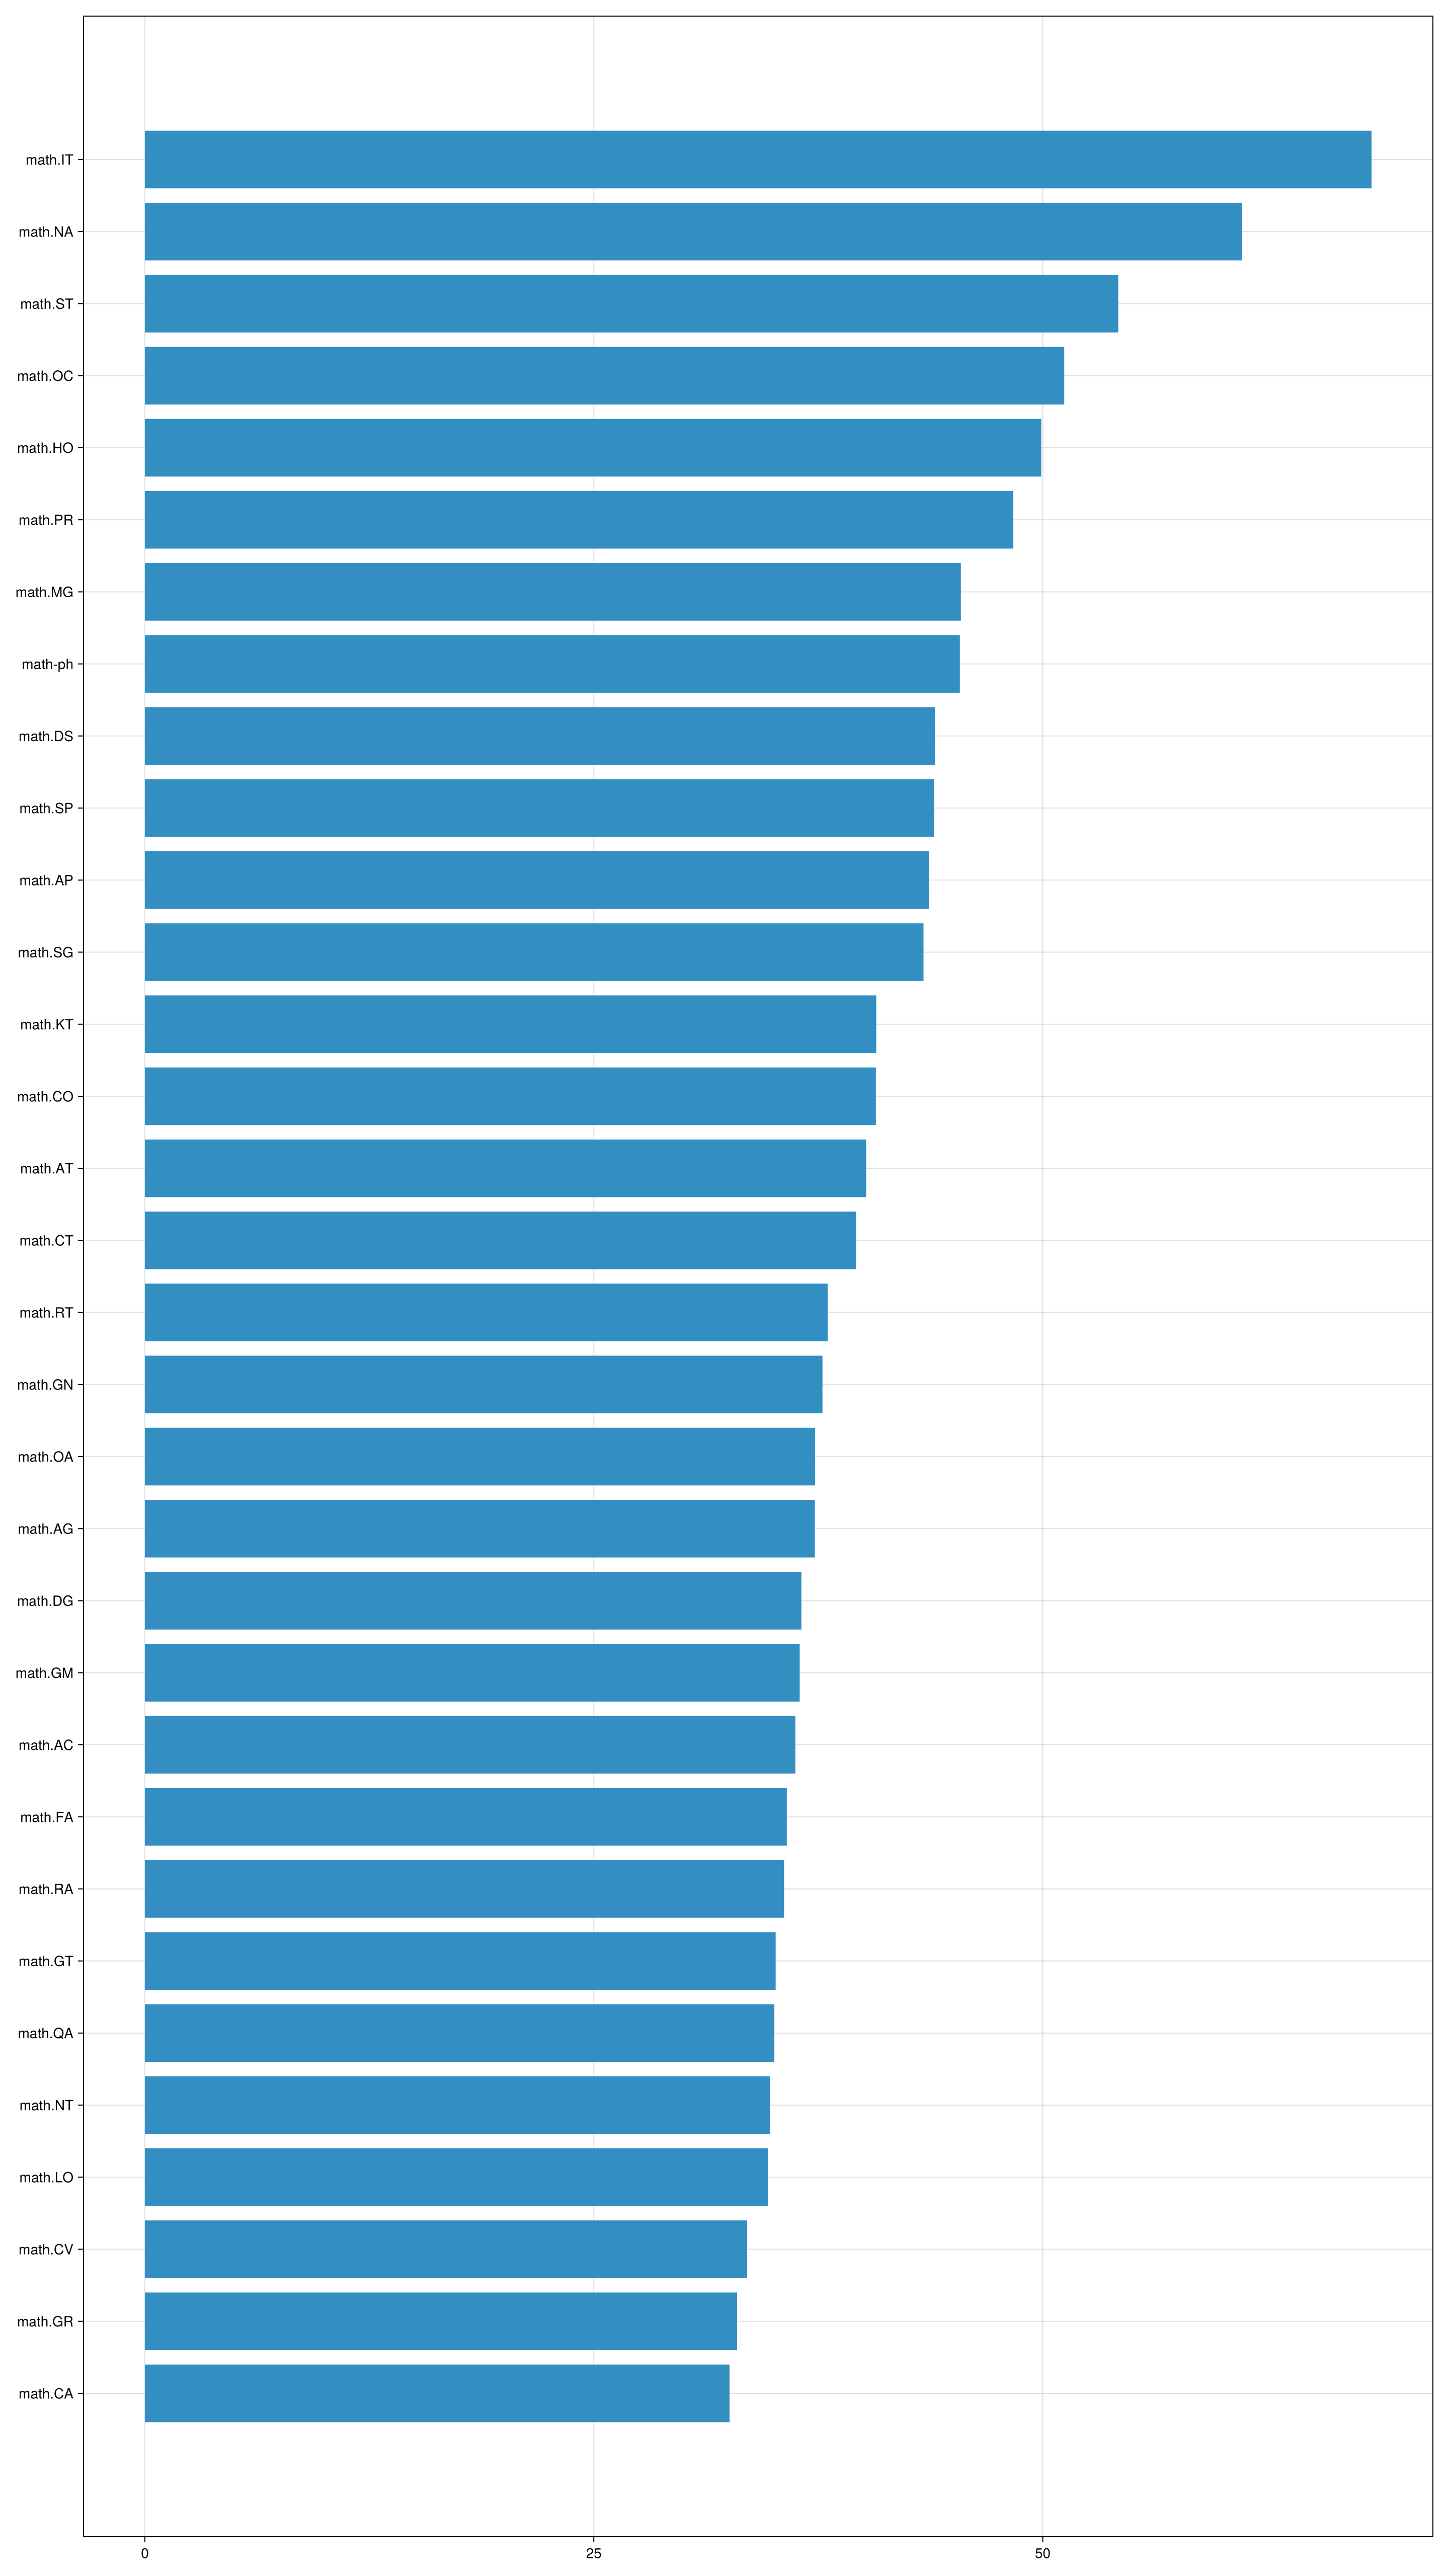

In [7]:
function abstract_vs_category_sort(df::DataFrame)
    category_counts = df[:, :categories] |> unique .|> (e -> e => [0, 0]) |> Dict
    for (name, alen) in zip(df[:, :categories], df[:, :abstract])
        category_counts[name][1] += alen |> length
        category_counts[name][2] += 1
    end
    categories = category_counts |> collect .|> (p -> p.first => p.second[1] / p.second[2])
    sorted_names = sort(categories, by=last)
    tick_names = sorted_names .|> first
    fig = Figure(size=(1440, 2560))
    ax = Axis(
        fig[1,1],
        yticks=(eachindex(tick_names), tick_names),
    )
    barplot!(ax, sorted_names .|> last; direction=:x)
    return fig
end

abstract_vs_category_sort(df)

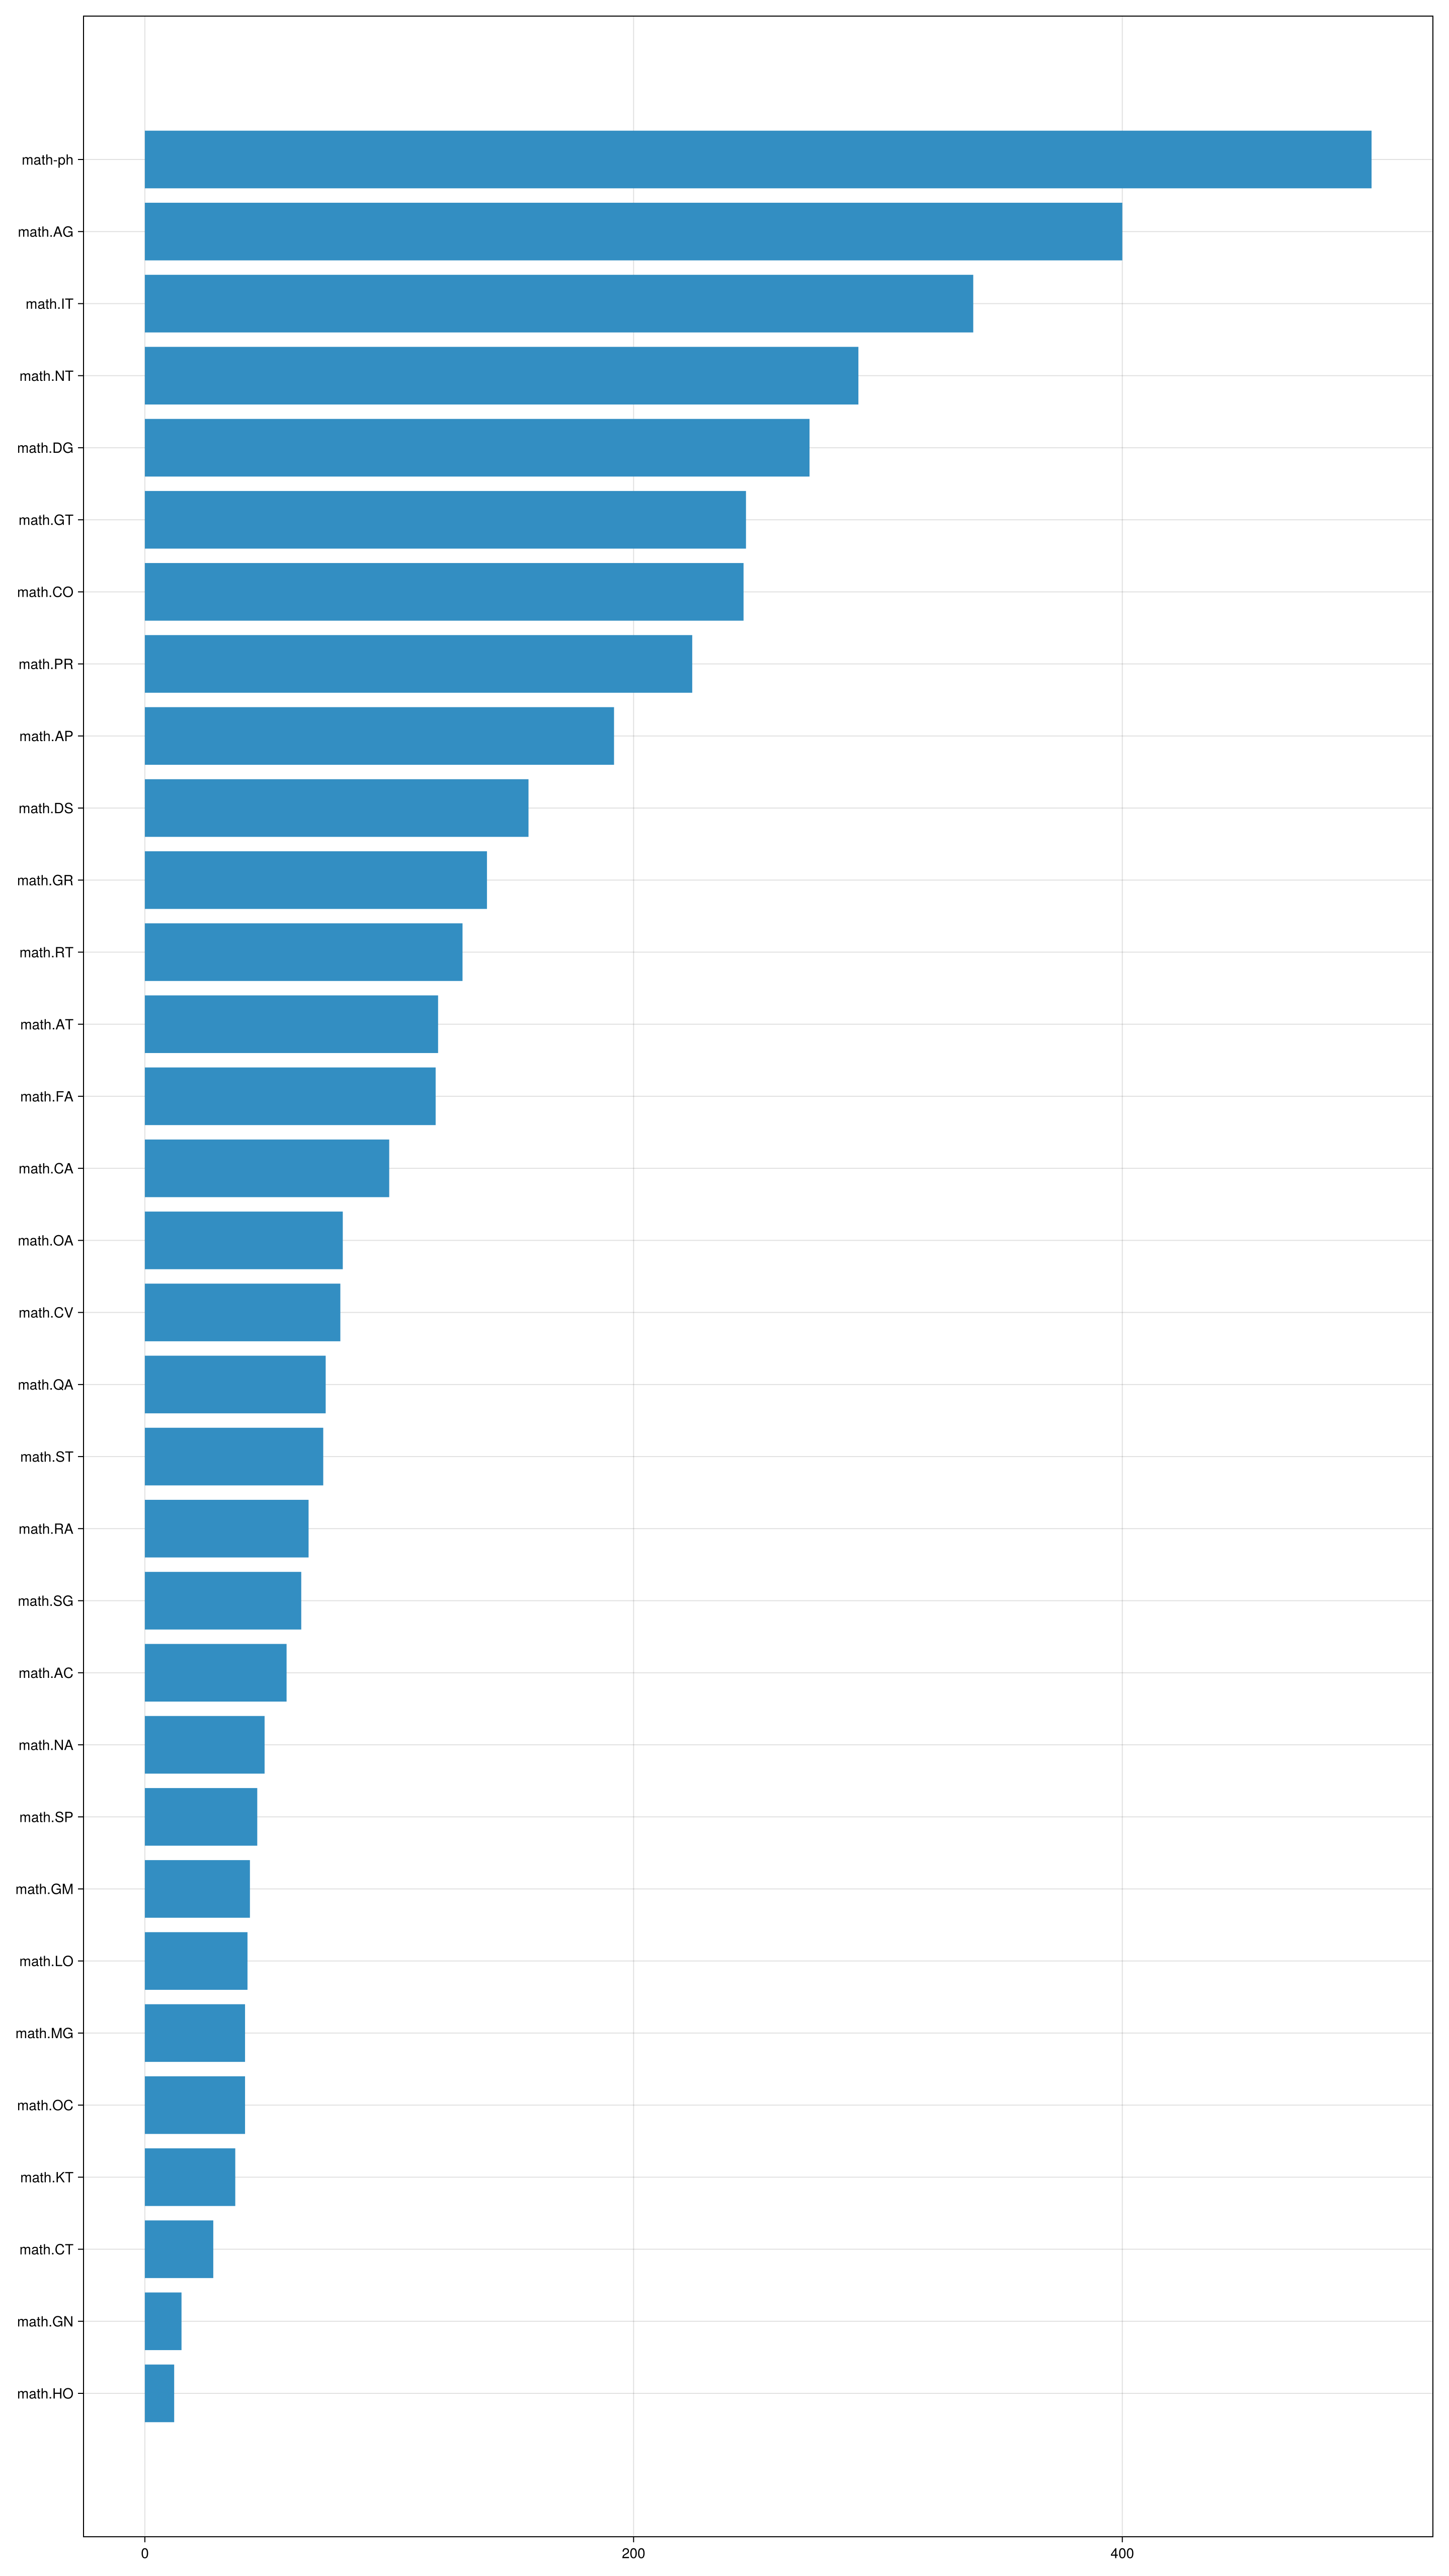

In [8]:
function article_types_sort(df::DataFrame)
    name_counts = df[:, :categories] |> unique .|> zero_pair |> Dict
    for name in df[:, :categories]
        name_counts[name] += 1
    end
    sorted_names = sort(name_counts |> collect, by=last)
    tick_names = sorted_names .|> first
    fig = Figure(size=(1440, 2560))
    ax = Axis(
        fig[1,1],
        yticks=(eachindex(tick_names), tick_names),
    )
    barplot!(ax, sorted_names .|> last; direction=:x)
    return fig
end

article_types_sort(df)

In [9]:
length(unique(df[:, :categories]))

32

In [10]:
docs = [
    vcat(t, ab, at)
    for (t, ab, at) in zip(df.title, df.abstract, df.authors)
]

4329-element Vector{Vector{String}}:
 ["dyadic", "alpha", "dyadic", "compute", "hardy", "description", "result", "paper", "consequence", "alpha"  …  "norm", "spaces", "r^n", "special", "show", "h^p", "terms", "atoms", "Abu-Shammala Wael", "Torchinsky Alberto"]
 ["real", "linear", "pfaffians", "products", "hafnians", "functionals", "lieb", "constant", "semi-definite", "matrices"  …  "`real", "called", "determinants", "norm", "inequality", "functionals", "problem", "inequalities", "esz", "Frenkel Péter E."]
 ["hardy-lorentz", "r^n", "spaces", "infty", "singular", "interpolation", "paper", "spaces", "acting", "hardy-lorentz"  …  "elements", "consider", "discuss", "properties", "r^n", "behavior", "other", "decomposition", "Abu-Shammala Wael", "Torchinsky Alberto"]
 ["injectivity", "transcendental", "theorem", "koll", "approach", "compact", "neither", "harmonic", "give", "covering"  …  "differential", "sequence", "geometric", "uses", "open", "spectral", "koll", "complete", "type", "Fujino O

In [11]:
vocab = Dict{String,Int}()
next_id = 1
for tokens in docs
    for w in tokens
        if !haskey(vocab, w)
            vocab[w] = next_id
            next_id += 1
        end
    end
end

In [12]:
function build_corpus(docs_tokens, vocab)
    corpus = Vector{Vector{Tuple{Int,Int}}}(undef, length(docs_tokens))
    for i in 1:length(docs_tokens)
        tokens = docs_tokens[i]
        freq = Dict{Int,Int}()
        for w in tokens
            vid = vocab[w]
            freq[vid] = get(freq, vid, 0) + 1
        end
        corpus[i] = [(vid, freq[vid]) for vid in keys(freq)]
    end
    return corpus
end

build_corpus (generic function with 1 method)

In [13]:
X = build_corpus(docs, vocab)

4329-element Vector{Vector{Tuple{Int64, Int64}}}:
 [(5, 1), (16, 1), (12, 1), (8, 1), (17, 1), (1, 2), (19, 1), (6, 1), (11, 1), (9, 1), (14, 1), (3, 1), (7, 1), (4, 1), (13, 1), (15, 1), (2, 2), (10, 1), (18, 1)]
 [(35, 1), (20, 2), (52, 1), (24, 1), (28, 1), (30, 1), (37, 1), (23, 1), (53, 1), (22, 1)  …  (48, 1), (34, 1), (50, 1), (21, 2), (54, 1), (27, 1), (38, 1), (26, 1), (10, 1), (42, 1)]
 [(56, 1), (55, 2), (58, 1), (60, 1), (12, 2), (19, 1), (67, 1), (11, 2), (68, 1), (69, 1), (64, 1), (61, 1), (7, 1), (66, 1), (57, 1), (59, 1), (65, 1), (63, 1), (18, 1), (62, 1)]
 [(110, 1), (73, 2), (112, 1), (90, 1), (86, 1), (104, 1), (91, 1), (75, 1), (111, 1), (92, 1)  …  (101, 1), (78, 1), (105, 1), (72, 2), (83, 1), (99, 1), (89, 1), (80, 1), (96, 1), (97, 1)]
 [(114, 2), (123, 1), (136, 1), (117, 2), (145, 1), (164, 1), (115, 2), (153, 1), (151, 1), (139, 1)  …  (166, 1), (14, 1), (149, 1), (155, 1), (143, 1), (113, 2), (65, 1), (165, 1), (142, 1), (134, 1)]
 [(220, 1), (197, 1), (215

In [14]:
Random.seed!(1234)
N = length(X)

test_idx = randperm(N)[1:round(Int, 0.2*N)]
train_idx = setdiff(1:N, test_idx)

train_subset = X[train_idx]
test_subset  = X[test_idx]

866-element Vector{Vector{Tuple{Int64, Int64}}}:
 [(1860, 2), (2470, 1), (797, 1), (1268, 1), (4540, 2), (1946, 2), (697, 1), (1764, 1), (847, 2), (2563, 1)  …  (22943, 1), (4949, 1), (24102, 1), (16301, 2), (24101, 1), (897, 1), (3150, 2), (1435, 1), (4531, 2), (3418, 1)]
 [(684, 1), (1033, 1), (711, 1), (4111, 1), (2802, 1), (6, 1), (267, 1), (3688, 1), (1619, 1), (5781, 1)  …  (14, 1), (178, 1), (96, 1), (1044, 1), (97, 1), (1034, 1), (4297, 2), (496, 1), (1780, 1), (683, 1)]
 [(25031, 1), (3202, 1), (913, 1), (648, 2), (720, 1), (569, 1), (926, 1), (2442, 1), (15941, 1), (319, 1)  …  (713, 1), (3694, 1), (1217, 1), (2727, 1), (3701, 1), (1326, 1), (2190, 1), (2029, 1), (2978, 1), (1512, 1)]
 [(2217, 1), (15199, 1), (2523, 1), (2350, 1), (111, 1), (11, 1), (45, 1), (237, 2), (15197, 1), (2525, 1)  …  (3148, 1), (2527, 1), (1294, 1), (612, 1), (15198, 1), (2321, 1), (15196, 1), (2362, 1), (1779, 1), (15195, 1)]
 [(706, 1), (781, 1), (9510, 1), (7147, 2), (7146, 2), (5282, 2), (7129, 

In [15]:
println("Rozmiar train: ", length(train_subset))
println("Rozmiar test: ", length(test_subset))

Rozmiar train: 3463
Rozmiar test: 866


In [16]:
K = 30
V = length(vocab)
burnin  = 100
samples  = 200

lda = LDA(K, V)
run_LDA(lda, train_subset, test_subset, burnin, samples)

Burn-in (period=100)...
epoch=1
epoch=2
epoch=3
epoch=4
epoch=5
epoch=6
epoch=7
epoch=8
epoch=9
epoch=10
epoch=11
epoch=12
epoch=13
epoch=14
epoch=15
epoch=16
epoch=17
epoch=18
epoch=19
epoch=20
epoch=21
epoch=22
epoch=23
epoch=24
epoch=25
epoch=26
epoch=27
epoch=28
epoch=29
epoch=30
epoch=31
epoch=32
epoch=33
epoch=34
epoch=35
epoch=36
epoch=37
epoch=38
epoch=39
epoch=40
epoch=41
epoch=42
epoch=43
epoch=44
epoch=45
epoch=46
epoch=47
epoch=48
epoch=49
epoch=50
epoch=51
epoch=52
epoch=53
epoch=54
epoch=55
epoch=56
epoch=57
epoch=58
epoch=59
epoch=60
epoch=61
epoch=62
epoch=63
epoch=64
epoch=65
epoch=66
epoch=67
epoch=68
epoch=69
epoch=70
epoch=71
epoch=72
epoch=73
epoch=74
epoch=75
epoch=76
epoch=77
epoch=78
epoch=79
epoch=80
epoch=81
epoch=82
epoch=83
epoch=84
epoch=85
epoch=86
epoch=87
epoch=88
epoch=89
epoch=90
epoch=91
epoch=92
epoch=93
epoch=94
epoch=95
epoch=96
epoch=97
epoch=98
epoch=99
epoch=100
Sampling from the posterior...
epoch=1, PPL=9.461381845553387
epoch=2, PPL=9.3984394

In [17]:
lda.Ndk_mean

3463×30 Matrix{Float64}:
 0.005   0.01   1.855   0.06   0.15   0.1    …   0.195   0.02   0.645   3.3
 0.09    0.02   9.875   0.03   0.01   0.0        0.26    0.025  0.015   0.275
 0.025   0.025  0.035   0.025  0.03   0.0        0.09    0.005  0.03    0.06
 0.075   0.015  0.05    0.035  0.035  0.03       8.32    0.015  0.04    6.075
 0.285   0.09   0.02    0.3    3.97   0.025      0.09    0.115  0.015   0.26
 0.13    0.07   0.04    1.875  0.015  0.23   …   0.075   0.385  0.1     0.06
 0.555   0.005  0.47    2.49   0.015  0.095      0.095   0.17   0.005   0.16
 0.21    0.33   2.34    3.535  0.035  0.005      0.07    0.04   0.08    0.765
 1.13    0.015  0.035   0.005  0.015  0.175      0.035   0.055  0.005   0.06
 0.07    0.04   0.05    0.755  0.075  0.11       0.635   2.725  0.05    0.07
 0.94   11.36   0.1     0.005  0.06   0.09   …   0.545   0.015  0.02    1.215
 0.565   0.01   0.075   5.15   0.0    0.145      0.385   0.065  0.02    0.44
 0.02    0.0    0.515  17.645  0.005  0.02      

In [18]:
dominant_topics_test = map(d -> argmax(lda.Ndk_mean[d, :]), 1:size(test_subset, 1))

866-element Vector{Int64}:
 18
  3
 21
 11
 11
 21
 18
 18
 18
 16
 26
 13
  4
  ⋮
  8
 11
  8
  8
 26
  8
 11
  8
  8
 21
  7
 25

In [19]:
function plot_topic_words(lda, vocab, topic_id; top_n=10)
    id2word = Dict(v => k for (k,v) in vocab)

    word_counts = lda.Nkv_mean[topic_id, :]
    top_ids = sortperm(word_counts, rev=true)[1:top_n]

    words = [id2word[i] for i in top_ids]
    values = word_counts[top_ids]

    fig = Figure()
    ax = Axis(fig[1,1], yticks=(1:top_n, words))

    barplot!(ax, values; direction=:x)

    fig
end

plot_topic_words (generic function with 1 method)

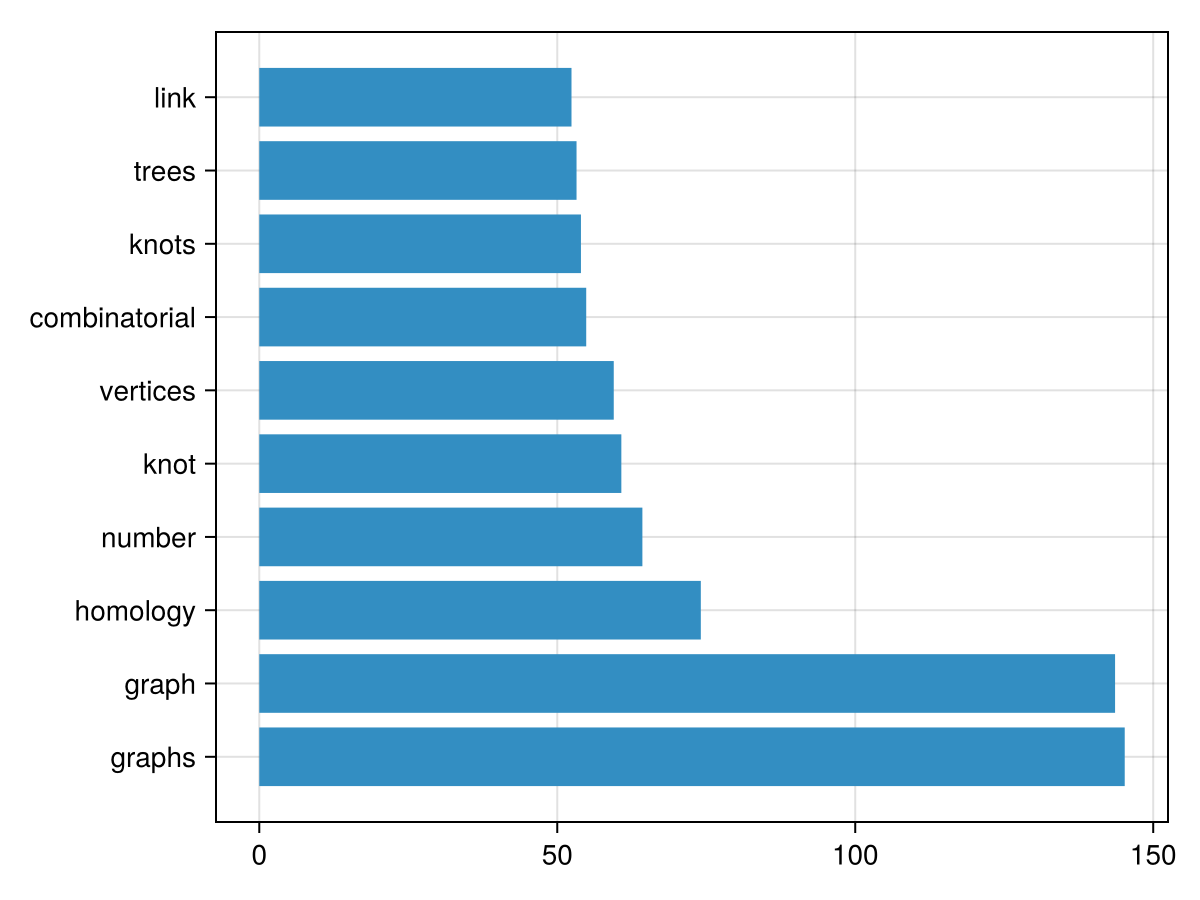

In [20]:
plot_topic_words(lda, vocab, 1)

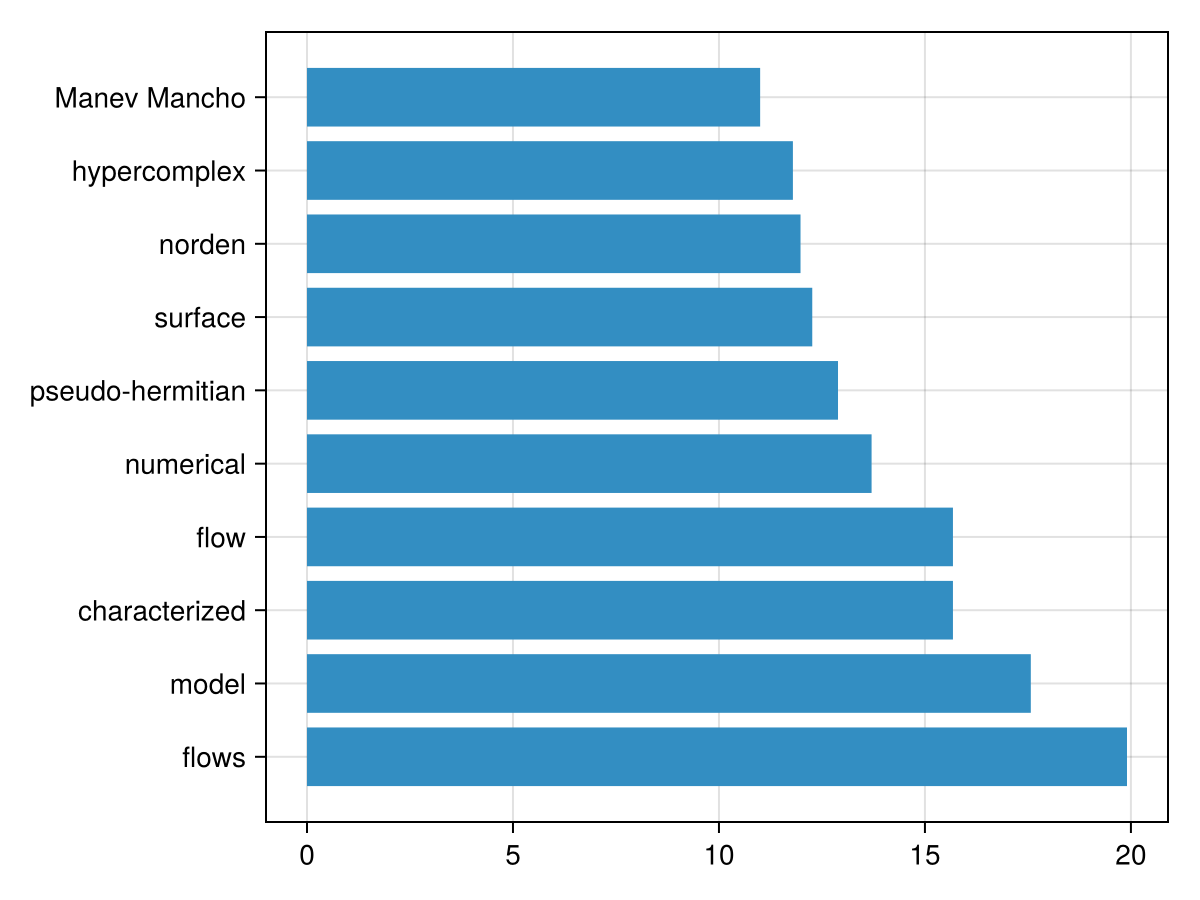

In [21]:
plot_topic_words(lda, vocab, 2)

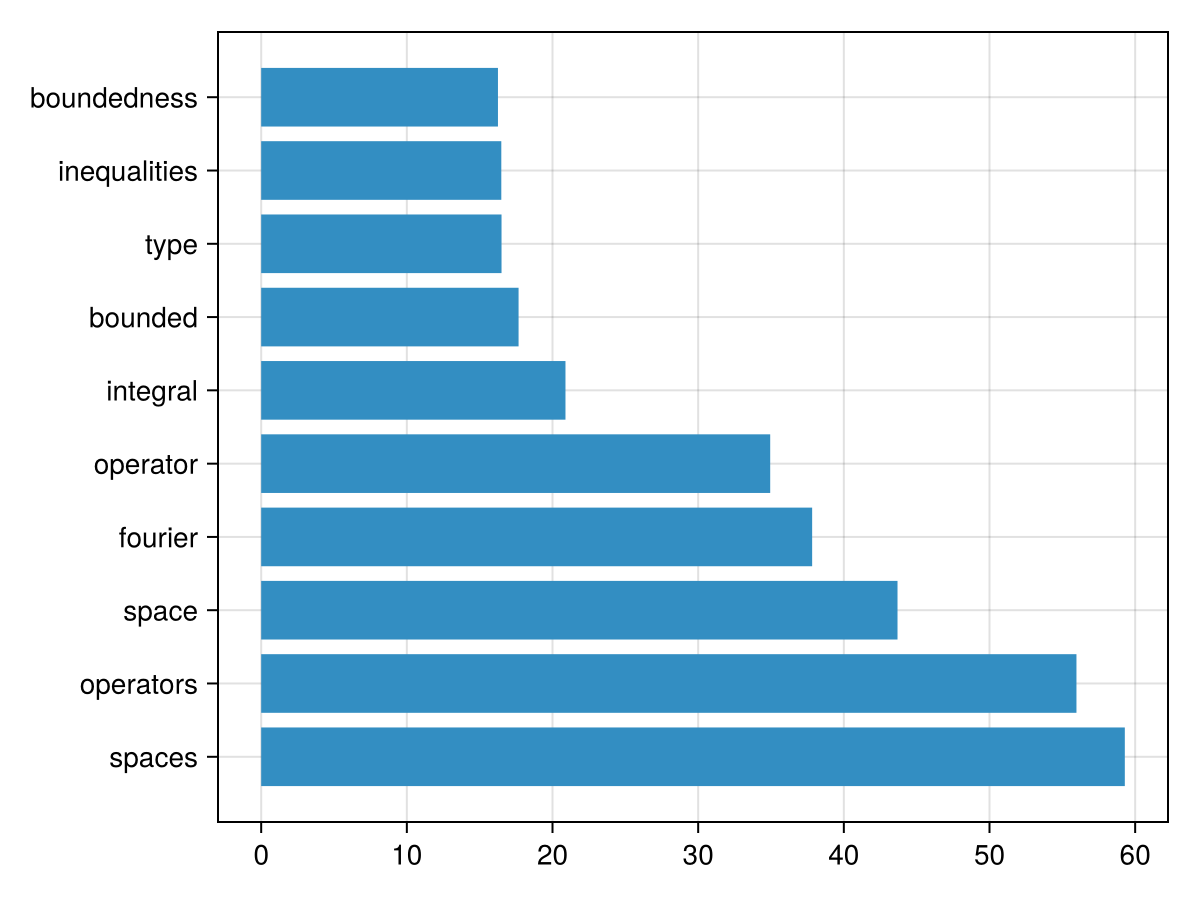

In [22]:
plot_topic_words(lda, vocab, 3)

In [23]:
word_weights = Dict{String, Float64}()
word_topic = Dict{String, Int}()
word_best_val = Dict{String, Float64}()

id2word = Dict(v => k for (k,v) in vocab)

Dict{Int64, String} with 25668 entries:
  19700 => "cb-multiplier"
  11950 => "finis"
  1703  => "represents"
  12427 => "Kubis Wieslaw"
  7685  => "dipole"
  18374 => "superstrictly"
  3406  => "subscheme"
  23970 => "doubts"
  2015  => "devices"
  1090  => "dependent"
  18139 => "superefficient"
  17088 => "ifn"
  11280 => "opulent"
  16805 => "Beck Matthias"
  3220  => "practical"
  11251 => "multimodal"
  422   => "because"
  15370 => "def"
  25327 => "professors"
  15859 => "pseudo-unitarizable"
  4030  => "paul"
  8060  => "multi-sample"
  14167 => "friction-induced"
  8660  => "replace"
  18475 => "castelnuovo--mumford"
  ⋮     => ⋮

In [24]:
top_n = 5

for i in 1:K
    word_counts = lda.Nkv_mean[i, :]

    top_ids = sortperm(word_counts, rev=true)[1:top_n]

    for j in top_ids
        word = id2word[j]
        val = word_counts[j]

        word_weights[word] = get(word_weights, word, 0.0) + val

        if !haskey(word_best_val, word) || val > word_best_val[word]
            word_best_val[word] = val
            word_topic[word] = i
        end
    end
end

In [25]:
colors = distinguishable_colors(K)

topic_color = Dict(i => colors[i] for i in 1:K)

Dict{Int64, RGB{FixedPointNumbers.N0f8}} with 30 entries:
  5  => RGB(0.886, 0.388, 0.051)
  16 => RGB(1.0, 0.361, 0.471)
  20 => RGB(1.0, 0.678, 0.027)
  12 => RGB(0.424, 0.322, 0.0)
  24 => RGB(0.369, 0.78, 0.0)
  28 => RGB(0.0, 0.561, 0.714)
  8  => RGB(0.675, 0.0, 0.278)
  17 => RGB(0.506, 0.592, 0.945)
  30 => RGB(0.769, 0.0, 0.0)
  1  => RGB(0.0, 0.0, 0.0)
  19 => RGB(0.78, 0.129, 0.867)
  22 => RGB(0.953, 1.0, 0.98)
  23 => RGB(0.0, 0.62, 0.533)
  6  => RGB(0.0, 0.494, 0.0)
  11 => RGB(1.0, 0.835, 0.769)
  9  => RGB(0.0, 1.0, 0.784)
  14 => RGB(0.267, 0.0, 0.361)
  3  => RGB(1.0, 0.608, 1.0)
  29 => RGB(0.812, 0.831, 0.992)
  7  => RGB(0.0, 0.314, 0.902)
  25 => RGB(0.0, 0.176, 0.329)
  4  => RGB(0.0, 0.827, 1.0)
  13 => RGB(0.478, 0.459, 0.506)
  15 => RGB(0.62, 0.62, 0.467)
  2  => RGB(1.0, 1.0, 0.455)
  ⋮  => ⋮

In [26]:
words = collect(keys(word_weights))

weights = [word_weights[w] for w in words]

colors_list = [
    haskey(word_topic, w) ? topic_color[word_topic[w]] : RGB(0.5,0.5,0.5)
    for w in words
]

angles = collect(0:5:180)
backgroundcolor = :maskcolor
shape(ellipse, 1000, 600, color="#8FB79C", padding=100, outline=4, linecolor="#ADEA821E")
▸1. Set spacing = 2; scale = 74.74149874931193
Completed after 65 epochs.


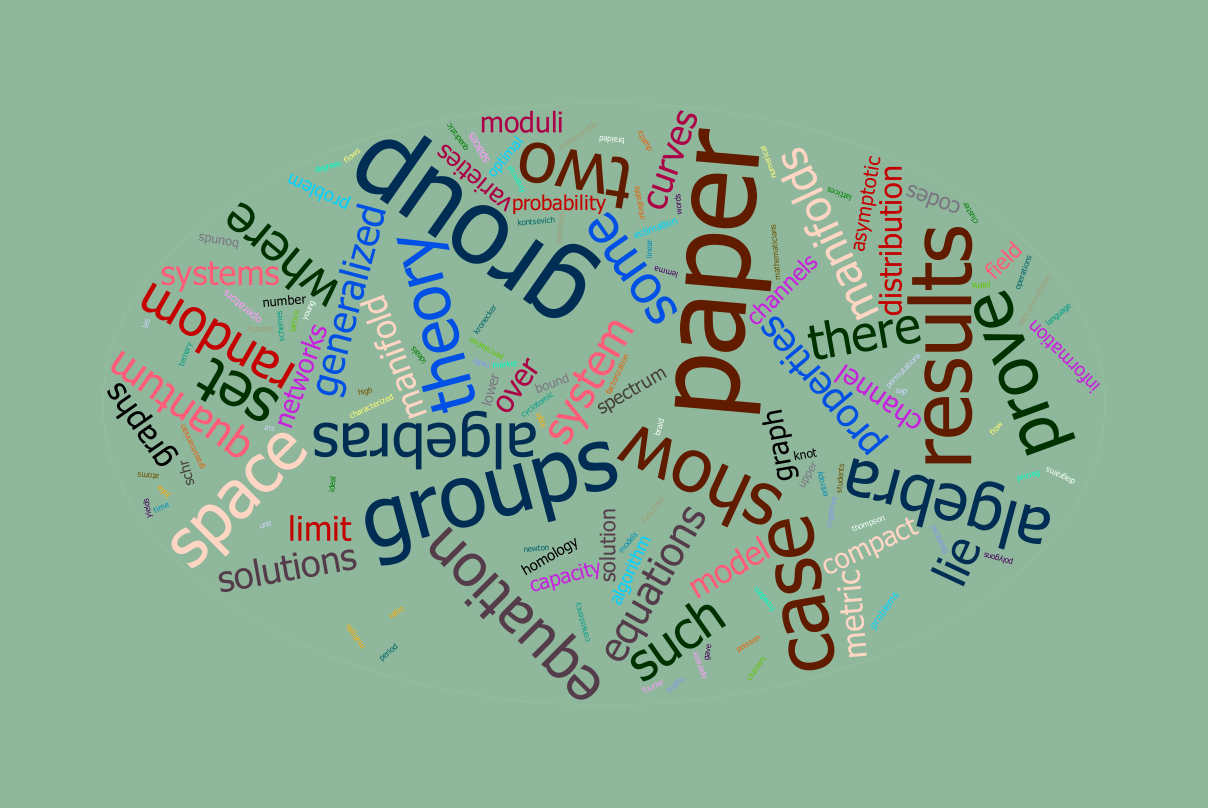

In [27]:
wc = wordcloud(
    words,
    weights;
    colors = colors_list,
    fonts = "Sans Not-Rotated",
    masksize = (1000, 600)
)

generate!(wc)

In [38]:
function eval_perplexity(x)
    return x.PPL
end


function build_topic_label_map(Ndk_mean, labels)

    K = size(Ndk_mean, 2)

    topic_to_labels = [Int[] for _ in 1:K]

    for d in 1:size(Ndk_mean, 1)

        topic = argmax(Ndk_mean[d, :])
        push!(topic_to_labels[topic], labels[d])
    end

    mapping = Dict{Int, Int}()

    for k in 1:K
        if isempty(topic_to_labels[k])
            continue
        end
        mapping[k] = mode(topic_to_labels[k])
    end

    return mapping
end

function majority_vote(v)

    counts = Dict{eltype(v), Int}()

    for x in v
        counts[x] = get(counts, x, 0) + 1
    end

    best_label = first(v)
    best_count = 0

    for (k, c) in counts
        if c > best_count
            best_label = k
            best_count = c
        end
    end

    return best_label
end

function lda_accuracy(Ndk_mean, labels)

    K = size(Ndk_mean, 2)

    topic_to_labels = [String[] for _ in 1:K]

    for d in 1:size(Ndk_mean, 1)

        topic = argmax(Ndk_mean[d, :])
        push!(topic_to_labels[topic], labels[d])
    end

    mapping = Dict{Int, String}()

    for k in 1:K

        if isempty(topic_to_labels[k])
            continue
        end

        mapping[k] = majority_vote(topic_to_labels[k])
    end

    correct = 0

    for d in 1:size(Ndk_mean, 1)

        topic = argmax(Ndk_mean[d, :])
        pred = get(mapping, topic, "")

        if pred == labels[d]
            correct += 1
        end
    end

    return correct / length(labels)
end

function lda_topic_purity(Ndk_mean, labels)

    K = size(Ndk_mean, 2)

    topic_labels = [String[] for _ in 1:K]

    for d in 1:size(Ndk_mean, 1)
        push!(topic_labels[argmax(Ndk_mean[d, :])], labels[d])
    end

    total = 0
    correct = 0

    for k in 1:K

        if isempty(topic_labels[k])
            continue
        end

        majority = majority_vote(topic_labels[k])

        correct += count(x -> x == majority, topic_labels[k])
        total += length(topic_labels[k])
    end

    return correct / total
end

function lda_topic_diversity(Nkv_mean; top_n=10)

    K = size(Nkv_mean, 1)

    top_words = Set{Int}()

    for k in 1:K

        scores = Nkv_mean[k, :]

        top_ids = partialsortperm(scores, 1:top_n, rev=true)

        for id in top_ids
            push!(top_words, id)
        end
    end

    return length(top_words) / (K * top_n)
end

function lda_coherence(Nkv_mean; top_n=10)

    K = size(Nkv_mean, 1)
    coherences = Float32[]

    for k in 1:K

        scores = Nkv_mean[k, :]
        top_ids = partialsortperm(scores, 1:top_n, rev=true)

        # proxy coherence: similarity in probability space
        sim = 0f0
        count = 0

        for i in 1:length(top_ids), j in i+1:length(top_ids)
            sim += min(scores[top_ids[i]], scores[top_ids[j]])
            count += 1
        end

        push!(coherences, sim / max(count, 1))
    end

    return mean(coherences)
end

function evaluate_lda(x, Ndk_mean, labels)

    println("=== LDA EVALUATION ===")

    ppl = x.PPL
    println("Perplexity: ", ppl)

    acc = lda_accuracy(Ndk_mean, labels)
    println("Accuracy (mapped topics): ", acc)

    purity = lda_topic_purity(Ndk_mean, labels)
    println("Topic purity: ", purity)

    div = lda_topic_diversity(x.Nkv_mean)
    println("Topic diversity: ", div)

    coh = lda_coherence(x.Nkv_mean)
    println("Topic coherence (proxy): ", coh)

    return (
        perplexity = ppl,
        accuracy = acc,
        purity = purity,
        diversity = div,
        coherence = coh
    )
end


evaluate_lda (generic function with 1 method)

In [39]:
evaluate_lda(lda, lda.Ndk_mean, df[train_idx, :].categories)

=== LDA EVALUATION ===
Perplexity: 9.154762961445211
Accuracy (mapped topics): 0.38059485994802195
Topic purity: 0.38059485994802195
Topic diversity: 0.8633333333333333
Topic coherence (proxy): 63.07748


(perplexity = 9.154762961445211, accuracy = 0.38059485994802195, purity = 0.38059485994802195, diversity = 0.8633333333333333, coherence = 63.07748f0)

In [40]:
include("BERTopicJL.jl")

run_pipeline (generic function with 1 method)

In [41]:
labels = df[!, :categories]

unique_labels = unique(labels)
label_to_idx = Dict(l => i for (i, l) in enumerate(unique_labels))

labels_encoded = [label_to_idx[l] for l in labels]

4329-element Vector{Int64}:
  1
  1
  1
  2
  3
  4
  3
  5
  6
  7
  8
  9
 10
  ⋮
  2
 24
  8
  9
  9
 23
 12
 22
  6
  6
 15
 10

In [42]:
function add_token!(vocab::Dict{String,Int}, token::AbstractString)
    if haskey(vocab, token)
        return vocab[token]
    else
        id = length(vocab) + 1
        vocab[token] = id
        return id
    end
end

add_token! (generic function with 1 method)

In [43]:
docs_encoded = [ [add_token!(vocab, w) for w in t] for t in docs]

4329-element Vector{Vector{Int64}}:
 [1, 2, 1, 3, 4, 5, 6, 7, 8, 2  …  10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
 [20, 21, 22, 23, 24, 25, 26, 27, 28, 29  …  47, 48, 49, 10, 50, 25, 51, 52, 53, 54]
 [55, 12, 11, 56, 57, 58, 7, 11, 59, 55  …  63, 64, 65, 66, 12, 67, 68, 69, 18, 19]
 [70, 71, 72, 73, 74, 75, 76, 77, 78, 79  …  104, 105, 106, 107, 108, 109, 73, 110, 111, 112]
 [113, 114, 75, 115, 116, 117, 118, 119, 120, 121  …  161, 65, 162, 116, 102, 163, 164, 165, 166, 167]
 [168, 169, 170, 171, 172, 173, 174, 175, 81, 176  …  213, 214, 161, 215, 216, 217, 16, 218, 219, 220]
 [221, 222, 114, 223, 224, 225, 226, 175, 227, 34  …  273, 274, 275, 72, 276, 277, 278, 279, 110, 280]
 [281, 282, 283, 284, 285, 249, 197, 44, 201, 286  …  281, 5, 282, 113, 283, 284, 288, 285, 289, 290]
 [291, 292, 293, 294, 295, 294, 78, 296, 297, 125  …  14, 46, 321, 295, 282, 322, 163, 323, 324, 325]
 [326, 84, 327, 11, 328, 329, 330, 331, 332, 333  …  356, 357, 358, 359, 360, 161, 361, 12, 362, 363]
 [364, 365,

In [44]:
dataset = DataSet(
    docs_encoded,
    labels_encoded
)

DataSet([[1, 2, 1, 3, 4, 5, 6, 7, 8, 2  …  10, 11, 12, 13, 14, 15, 16, 17, 18, 19], [20, 21, 22, 23, 24, 25, 26, 27, 28, 29  …  47, 48, 49, 10, 50, 25, 51, 52, 53, 54], [55, 12, 11, 56, 57, 58, 7, 11, 59, 55  …  63, 64, 65, 66, 12, 67, 68, 69, 18, 19], [70, 71, 72, 73, 74, 75, 76, 77, 78, 79  …  104, 105, 106, 107, 108, 109, 73, 110, 111, 112], [113, 114, 75, 115, 116, 117, 118, 119, 120, 121  …  161, 65, 162, 116, 102, 163, 164, 165, 166, 167], [168, 169, 170, 171, 172, 173, 174, 175, 81, 176  …  213, 214, 161, 215, 216, 217, 16, 218, 219, 220], [221, 222, 114, 223, 224, 225, 226, 175, 227, 34  …  273, 274, 275, 72, 276, 277, 278, 279, 110, 280], [281, 282, 283, 284, 285, 249, 197, 44, 201, 286  …  281, 5, 282, 113, 283, 284, 288, 285, 289, 290], [291, 292, 293, 294, 295, 294, 78, 296, 297, 125  …  14, 46, 321, 295, 282, 322, 163, 323, 324, 325], [326, 84, 327, 11, 328, 329, 330, 331, 332, 333  …  356, 357, 358, 359, 360, 161, 361, 12, 362, 363]  …  [4167, 25624, 249, 25625, 939, 331,

In [ ]:
 model = run_pipeline(
        dataset;
        vocab_size=length(vocab)
    )

Preparing data...
Init embedder...


In [ ]:
function doc_topic_matrix(model::TopicModel, docs)
    N = length(docs)
    K = length(model.topic_centroids)

    M = zeros(Float32, N, K)

    for i in 1:N
        d = embed(model.embedder, docs[i])

        for k in 1:K
            M[i, k] = cosine(d, model.topic_centroids[k])
        end
    end

    return M
end

function doc_topic_probs(model, docs)
    M = doc_topic_matrix(model, docs)
    for i in 1:size(M,1)
        v = M[i,:]
        v = exp.(v .- maximum(v))
        M[i,:] = v ./ sum(v)
    end
    return M
end

function topic_word_scores(model::TopicModel, vocab)
    id2word = Dict(v => k for (k, v) in vocab)

    V = maximum(values(vocab))
    K = length(model.topic_centroids)

    S = zeros(Float32, K, V)

    for (word, id) in vocab

        # embedding pojedynczego tokena
        wemb = embed(model.embedder, [id])

        for k in 1:K
            S[k, id] = cosine(model.topic_centroids[k], wemb)
        end
    end

    return S, id2word
end

function plot_topic_words(model::TopicModel, vocab, topic_id; top_n=10)

    S, id2word = topic_word_scores(model, vocab)

    word_scores = S[topic_id, :]

    top_ids = sortperm(word_scores, rev=true)[1:min(top_n, length(word_scores))]

    words = [id2word[i] for i in top_ids]
    values = word_scores[top_ids]

    fig = Figure()
    ax = Axis(fig[1, 1], yticks=(1:length(words), words))

    barplot!(ax, values; direction=:x)

    return fig
end

In [ ]:
plot_topic_words(model, vocab, 1)

In [ ]:
plot_topic_words(model, vocab, 2)

In [ ]:
plot_topic_words(model, vocab, 3)

In [ ]:
function ber_topic_wordcloud_global(model, vocab; top_n=5)

    S, id2word = topic_word_scores(model, vocab)

    K = size(S, 1)

    words = String[]
    weights = Float32[]
    colors = Any[]   # RGB per word

    # prosty generator kolorów per topic
    function topic_color(k)
        hue = (k * 0.6180339887) % 1  # golden ratio trick
        return RGB(hue, 0.6, 0.8)
    end

    for k in 1:K

        scores = S[k, :]

        valid_ids = findall(!iszero, scores)
        if isempty(valid_ids)
            continue
        end

        sorted_ids = sort(valid_ids, by=i -> scores[i], rev=true)
        sel = sorted_ids[1:min(top_n, length(sorted_ids))]

        for id in sel
            if haskey(id2word, id)

                push!(words, id2word[id])
                push!(weights, scores[id])
                push!(colors, topic_color(k))

            end
        end
    end

    if isempty(words)
        error("No words to plot")
    end

    wc = wordcloud(
        words,
        weights;
        colors = colors,
        masksize = (1000, 600)
    )

    return generate!(wc)
end

color scheme: :Pillement, random size: 6
angles = 0


[ Info: Initializing with default parameters.


Language: cat
fonts = "Cascadia Code Bold"
backgroundcolor = :maskcolor
shape(ellipse, 800, 400, color="#F2F2F2", padding=80, outline=8, linecolor="#FF44636F")
The word "Martell José Maria IMFF"(71.0753457831535) is too big. Set maxfontsize = 41.087942362118625.
The word "Martell José Maria IMFF"(113.25694539844302) is too big. Set maxfontsize = 41.7274724124241.
The word "Martell José Maria IMFF"(345.8364457559596) is too big. Set maxfontsize = 41.484025210084035.
The word "Martell José Maria IMFF"(345.8364457559596) is too big. Set maxfontsize = 41.484025210084035.
The word "Martell José Maria IMFF"(345.8364457559596) is too big. Set maxfontsize = 41.484025210084035.
▸1. Set spacing = 2; scale = 3992.616512138427
Completed after 24 epochs.


┌ Warning: The `findscale!` has performed `maxiter`(5) iterations. The set `density` is not reached. This may be caused by too small background, too big `minfontsize` or unsuitable number of words.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\strategy.jl:152
┌ Warning: Some words are limited to the maximum font size. Please set a `maxfontsize` in `wordcloud` or set a `maxweight` in `processtext`.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\wc-method.jl:67


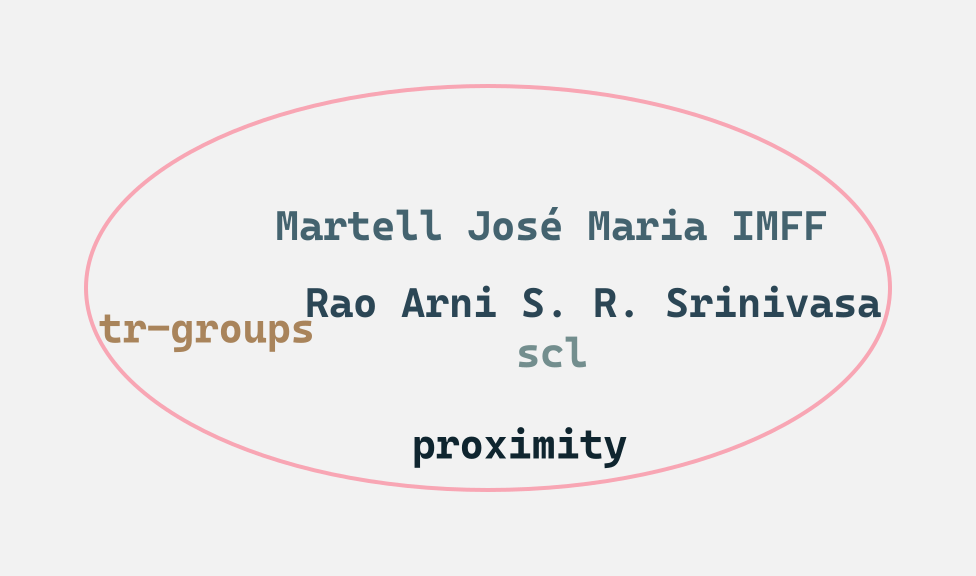

color scheme: :Set1_5, random size: 1, shuffled
angles = 90:-1:-90
Language: eng
fonts = "Microsoft New Tai Lue"
shape(squircle, 800, 400, rt=2.0, color="#E5E7E6", padding=80)
The word "completely"(59.25883585432138) is too big. Set maxfontsize = 53.798140171356216.
The word "completely"(62.37772195191725) is too big. Set maxfontsize = 53.63927819760026.
The word "Helleloid Geir T."(70.92882956874968) is too big. Set maxfontsize = 65.82835433633163.
The word "completely"(65.82835433633163) is too big. Set maxfontsize = 53.93639572941738.
The word "reinterpret"(206.37904150718586) is too big. Set maxfontsize = 101.32900329531562.
The word "Helleloid Geir T."(101.32900329531562) is too big. Set maxfontsize = 65.38574389669371.
gathering style: use the parameter in wordcloud `:rt=>2.0`
▸1. Set spacing = 2; scale = 551.7041203730638


┌ Warning: The `findscale!` has performed `maxiter`(5) iterations. The set `density` is not reached. This may be caused by too small background, too big `minfontsize` or unsuitable number of words.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\strategy.jl:152
┌ Warning: Some words are limited to the maximum font size. Please set a `maxfontsize` in `wordcloud` or set a `maxweight` in `processtext`.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\wc-method.jl:67


Aborted after 47 epochs.
▸2. Try setting spacing = 1
Aborted after 90 epochs.
The word "reinterpret"(154.99261224825483) is too big. Set maxfontsize = 101.14564268800392.
The word "Helleloid Geir T."(101.14564268800392) is too big. Set maxfontsize = 65.83251059390822.
▸3. Try setting scale = 535.1529967618719. The density will be reduced to 0.5952876256281407
Failed after 137 epochs.
These words collide: #MASK# & reinterpret, Helleloid Geir T. & non-trivially, Helleloid Geir T. & completely, Mina Teicher & non-trivially, completely & non-trivially, 


┌ Warning: Some words are limited to the maximum font size. Please set a `maxfontsize` in `wordcloud` or set a `maxweight` in `processtext`.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\wc-method.jl:67
┌ Warning: There are 5 collisions detected. To address this, you might consider increasing the `epochs` or `retry` parameters within the `generate!` function, or reducing the `density` or `spacing` parameters in the `wordcloud` function.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\wc-method.jl:288


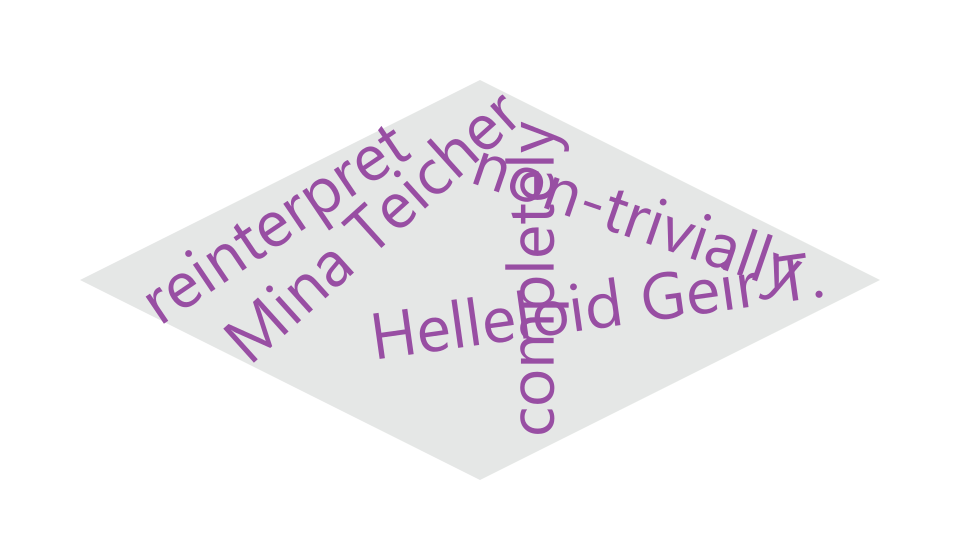

color scheme: :tableau_red_blue, random size: 7, shuffled
angles = [0, 45, 90]
Language: ita
fonts = "Microsoft JhengHei Light"
backgroundcolor = :maskcolor
shape(squircle, 800, 400, rt=0.939, color="#1C1C16", padding=80, outline=8, linecolor="#FF5383AF")
▸1. Set spacing = 2; scale = 244.96555772627133
Aborted after 46 epochs.
▸2. Try setting spacing = 1
Aborted after 89 epochs.
▸3. Try setting scale = 237.61659099448318. The density will be reduced to 0.46918424385515045
Failed after 180 epochs.
These words collide: #MASK# & riccati, quantum & bicomplete, quantum & riccati, riccati & sigma-unital, 


┌ Warning: There are 4 collisions detected. To address this, you might consider increasing the `epochs` or `retry` parameters within the `generate!` function, or reducing the `density` or `spacing` parameters in the `wordcloud` function.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\wc-method.jl:288


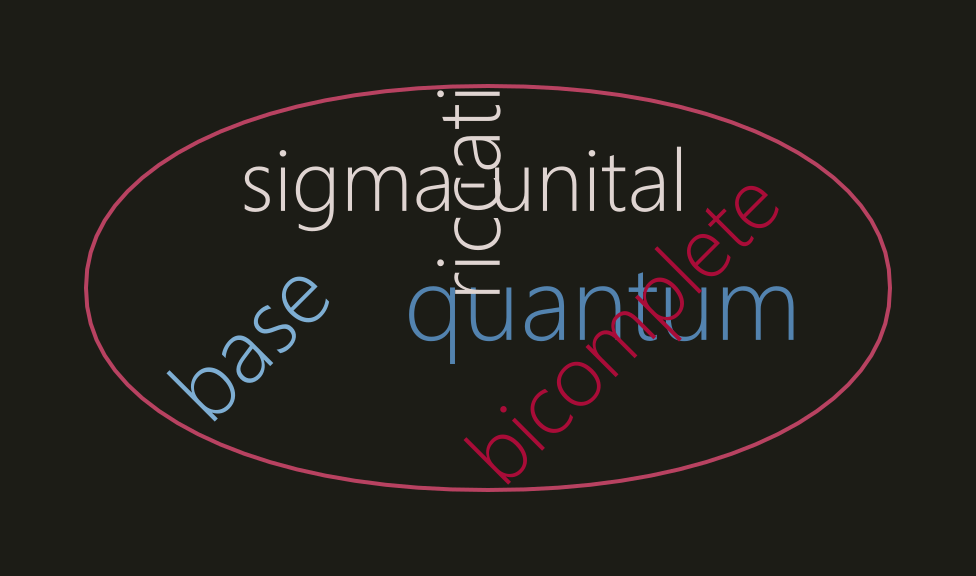

color scheme: :Set3_7, random size: 7
angles = collect(0:180)
Language: eng
fonts = ["Georgia Normal", "MS PGothic Bold"]
backgroundcolor = :maskcolor
shape(box, 800, 400, cornerradius=12, color="#6E655E", padding=80)
The word "estimation-induced"(93.42752180481071) is too big. Set maxfontsize = 79.2975853877066.
The word "estimation-induced"(98.3447597945376) is too big. Set maxfontsize = 79.62848122119955.
The word "estimation-induced"(108.96926293023556) is too big. Set maxfontsize = 80.04251186119767.
The word "satisfies"(345.46343518727457) is too big. Set maxfontsize = 182.55892951760802.
The word "estimation-induced"(182.55892951760802) is too big. Set maxfontsize = 79.7184855793133.


┌ Warning: The `findscale!` has performed `maxiter`(5) iterations. The set `density` is not reached. This may be caused by too small background, too big `minfontsize` or unsuitable number of words.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\strategy.jl:152
┌ Warning: Some words are limited to the maximum font size. Please set a `maxfontsize` in `wordcloud` or set a `maxweight` in `processtext`.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\wc-method.jl:67


▸1. Set spacing = 2; scale = 1361.1385844812655
Completed after 31 epochs.


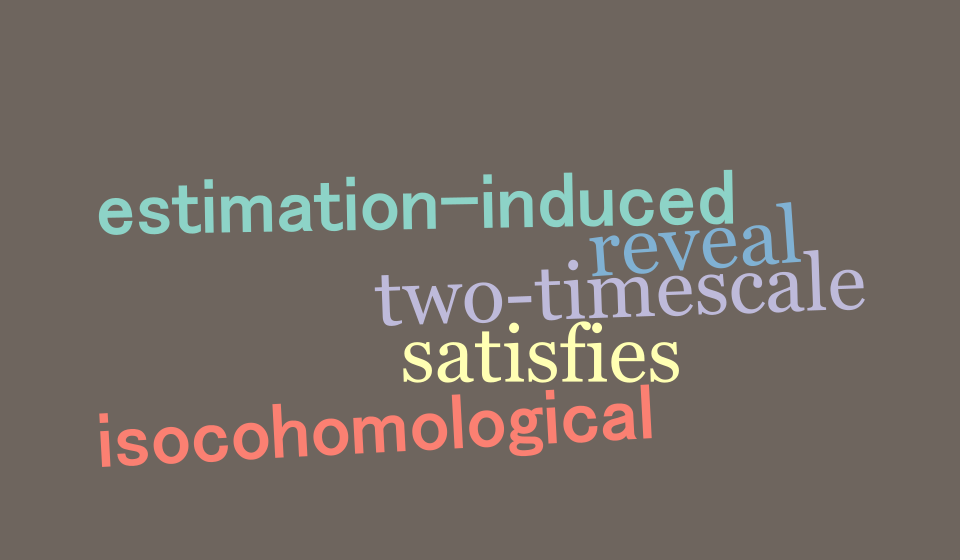

color scheme: :Nizami, random size: 8, shuffled
angles = -90:15:90
Language: eng
fonts = "Verdana Bold"
shape(ellipse, 800, 400, color="#150F10", padding=80)
The word "rederiving"(77.0327737814219) is too big. Set maxfontsize = 67.10014160432411.
The word "postcritical"(67.10014160432411) is too big. Set maxfontsize = 53.19767467366582.
The word "rederiving"(101.47384082131614) is too big. Set maxfontsize = 67.14521056757589.
The word "postcritical"(67.14521056757589) is too big. Set maxfontsize = 52.97623959446047.
The word "rederiving"(106.81456928559594) is too big. Set maxfontsize = 66.92213677831484.
The word "postcritical"(66.92213677831484) is too big. Set maxfontsize = 53.31536307942623.
The word "rederiving"(343.82925268219986) is too big. Set maxfontsize = 67.29718611814809.
The word "postcritical"(67.29718611814809) is too big. Set maxfontsize = 53.09614529006493.
The word "rederiving"(343.82925268219986) is too big. Set maxfontsize = 67.29718611814809.
The word "postcritica

┌ Warning: The `findscale!` has performed `maxiter`(5) iterations. The set `density` is not reached. This may be caused by too small background, too big `minfontsize` or unsuitable number of words.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\strategy.jl:152
┌ Warning: Some words are limited to the maximum font size. Please set a `maxfontsize` in `wordcloud` or set a `maxweight` in `processtext`.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\wc-method.jl:67


Aborted after 134 epochs.
▸2. Try setting spacing = 1
Completed after 198 epochs.


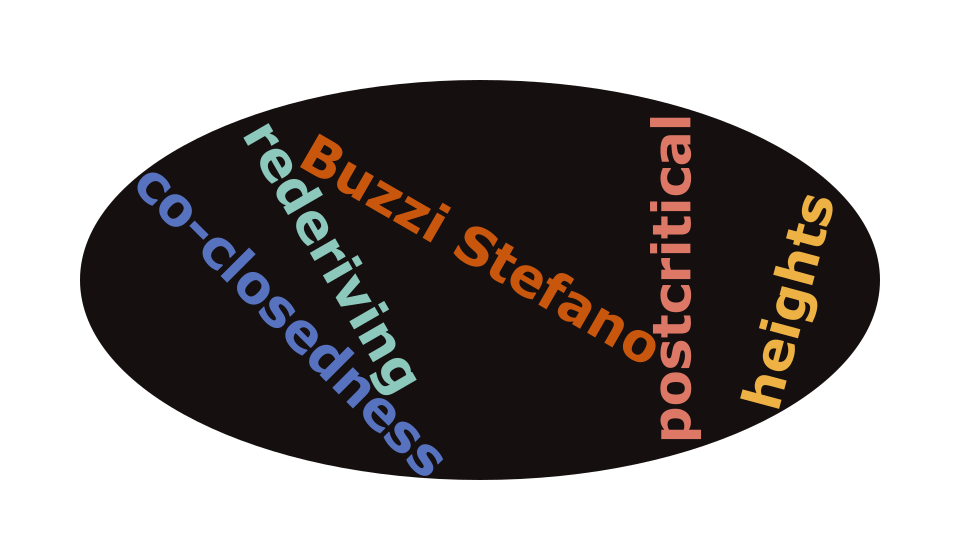

color scheme: :tableau_colorblind, random size: 4
angles = (0, -90)
Language: eng
fonts = "Constantia Light"
shape(squircle, 800, 400, rt=0.111, color="#080808", padding=80)
gathering style: use the parameter in wordcloud `:rt=>0.111`
▸1. Set spacing = 2; scale = 296.6884634676084
Completed after 15 epochs.


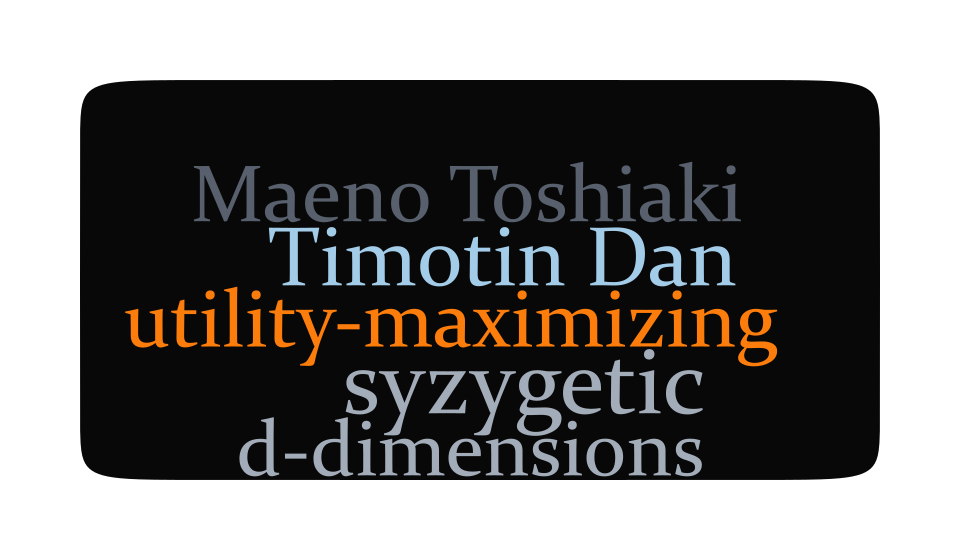

color scheme: :Accent_5, random size: 5
angles = (0, -45, -90, 45)
Language: eng
fonts = "Tahoma Regular"
backgroundcolor = :maskcolor
shape(ellipse, 800, 400, color="#171917", padding=80)
The word "appropriately"(83.57581075952697) is too big. Set maxfontsize = 56.5197062690875.
The word "appropriately"(128.22400120656658) is too big. Set maxfontsize = 56.6749721045149.
The word "appropriately"(134.97263284901746) is too big. Set maxfontsize = 56.44963189599908.
The word "appropriately"(343.82925268219986) is too big. Set maxfontsize = 56.77837575834178.
▸1. Set spacing = 2; scale = 2078.273733844414
Completed after 7 epochs.


┌ Warning: Extra large font size detected. The density 0.5 may be unreachable.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\strategy.jl:195
┌ Warning: Some words are limited to the maximum font size. Please set a `maxfontsize` in `wordcloud` or set a `maxweight` in `processtext`.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\wc-method.jl:67


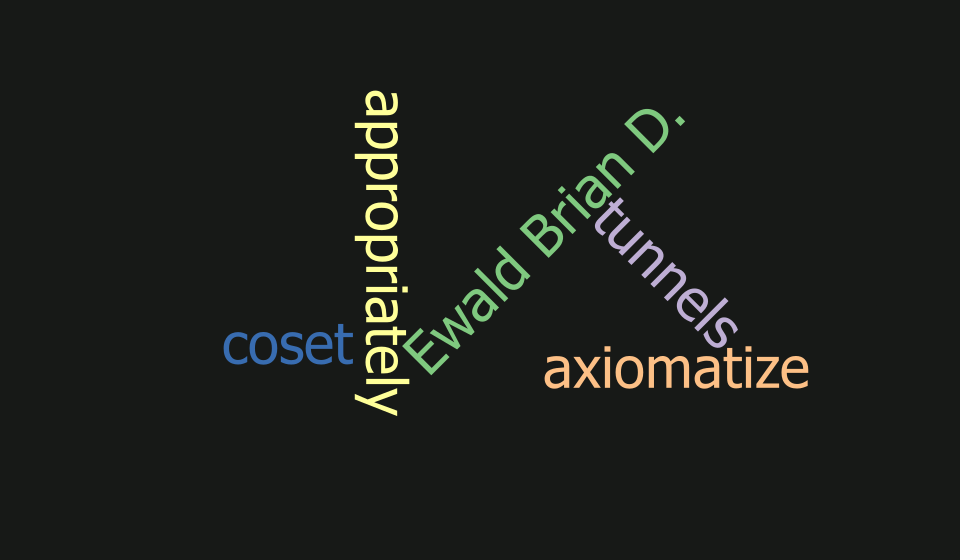

colors = 0.5830986475788156
angles = collect(-5:5)
Language: eng
fonts = "MingLiU-ExtB Bold"
shape(squircle, 800, 400, rt=0.036, color="#14232A", padding=80)
The word "Ratcliffe John G."(82.78726125643658) is too big. Set maxfontsize = 76.6095406274049.
The word "segal-shale-weil"(93.85911529600332) is too big. Set maxfontsize = 81.27911375599707.
The word "Ratcliffe John G."(81.27911375599707) is too big. Set maxfontsize = 75.32389544746238.
The word "segal-shale-weil"(98.79906873263508) is too big. Set maxfontsize = 82.0854097315319.
The word "Ratcliffe John G."(82.0854097315319) is too big. Set maxfontsize = 75.96006240943315.
The word "segal-shale-weil"(192.17661205228254) is too big. Set maxfontsize = 81.65004213767365.
The word "Ratcliffe John G."(81.65004213767365) is too big. Set maxfontsize = 75.55718265639692.
The word "segal-shale-weil"(388.27899119061277) is too big. Set maxfontsize = 81.71824542017025.
The word "Ratcliffe John G."(81.71824542017025) is too big. Set maxfont

┌ Warning: The `findscale!` has performed `maxiter`(5) iterations. The set `density` is not reached. This may be caused by too small background, too big `minfontsize` or unsuitable number of words.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\strategy.jl:152
┌ Warning: Some words are limited to the maximum font size. Please set a `maxfontsize` in `wordcloud` or set a `maxweight` in `processtext`.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\wc-method.jl:67


▸1. Set spacing = 2; scale = 325.59309267473
Aborted after 128 epochs.
▸2. Try setting spacing = 1
Completed after 129 epochs.


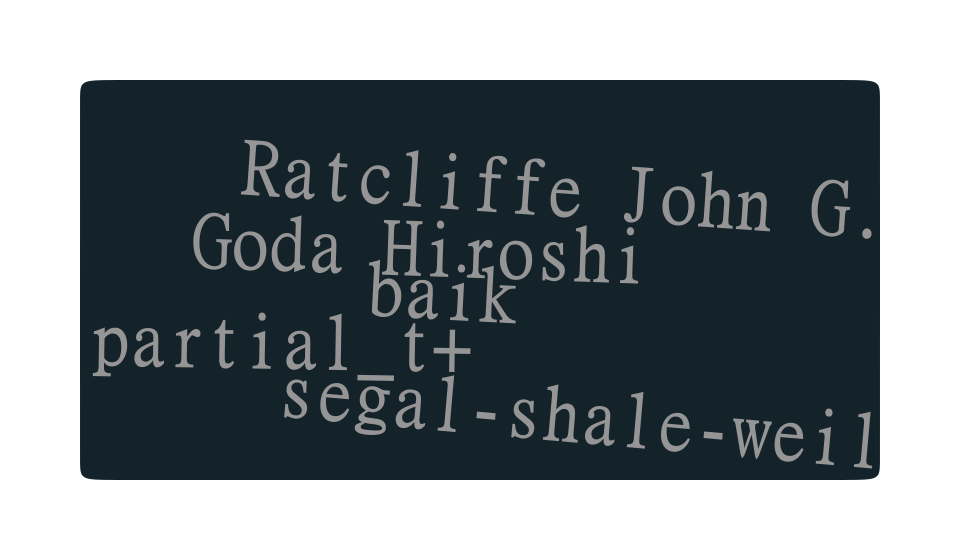

color scheme: :tableau_sunset_sunrise, random size: 4, shuffled
angles = [30, -30]
Language: eng
fonts = "Segoe UI Symbol"
backgroundcolor = :maskcolor
shape(squircle, 800, 400, rt=0.696, color="#000000", padding=80, outline=2, linecolor="#AAC9E087")
▸1. Set spacing = 2; scale = 270.4738468376023
Aborted after 124 epochs.
▸2. Try setting spacing = 1
Aborted after 207 epochs.
▸3. Try setting scale = 262.35963143247426. The density will be reduced to 0.46987077042365766
Failed after 351 epochs.
These words collide: #MASK# & h--hyperspecial, h--hyperspecial & cdots+x_n, 


┌ Warning: There are 2 collisions detected. To address this, you might consider increasing the `epochs` or `retry` parameters within the `generate!` function, or reducing the `density` or `spacing` parameters in the `wordcloud` function.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\wc-method.jl:288


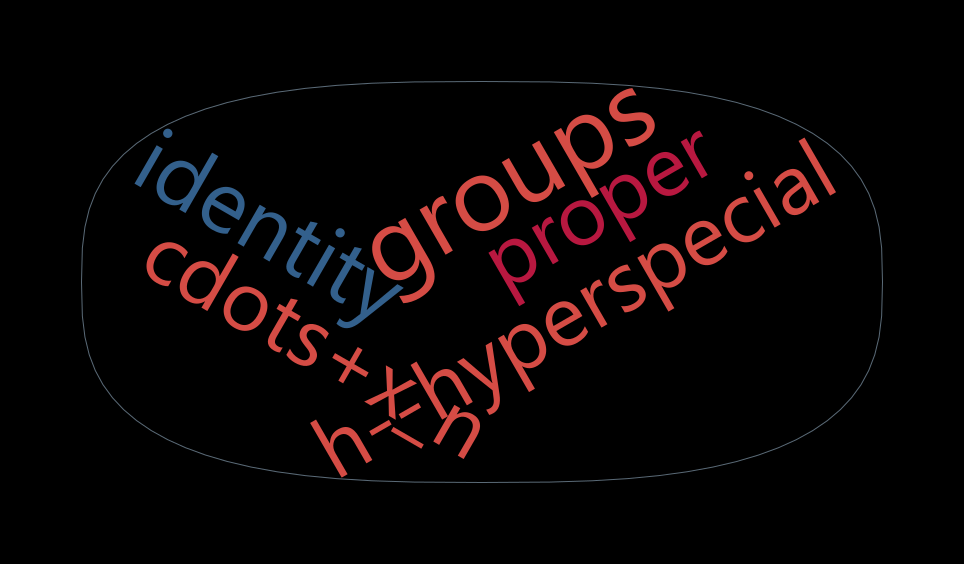

color scheme: :tableau_winter, random size: 4
angles = (60, -60)
Language: ina
fonts = "Cascadia Mono Bold"
backgroundcolor = :maskcolor
shape(squircle, 800, 400, rt=0.403, color="#020202", padding=80, outline=10, linecolor="#FFB9A0B4")
The word "Pimentel Leandro P. R."(92.68027461971404) is too big. Set maxfontsize = 33.19085317551095.
The word "palmieri"(252.55843297497452) is too big. Set maxfontsize = 91.1503141766763.
The word "Pimentel Leandro P. R."(91.1503141766763) is too big. Set maxfontsize = 33.270689408608646.
The word "palmieri"(265.85098207892054) is too big. Set maxfontsize = 91.06766849653683.
The word "Pimentel Leandro P. R."(91.06766849653683) is too big. Set maxfontsize = 33.24052298757412.
The word "palmieri"(380.6595071821578) is too big. Set maxfontsize = 91.24691390418249.
The word "Pimentel Leandro P. R."(91.24691390418249) is too big. Set maxfontsize = 33.305949183189185.


┌ Warning: Extra large font size detected. The density 0.5 may be unreachable.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\strategy.jl:195
┌ Warning: Some words are limited to the maximum font size. Please set a `maxfontsize` in `wordcloud` or set a `maxweight` in `processtext`.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\wc-method.jl:67


gathering style: use the parameter in wordcloud `:rt=>0.403`
▸1. Set spacing = 2; scale = 4271.6999255667
Completed after 14 epochs.


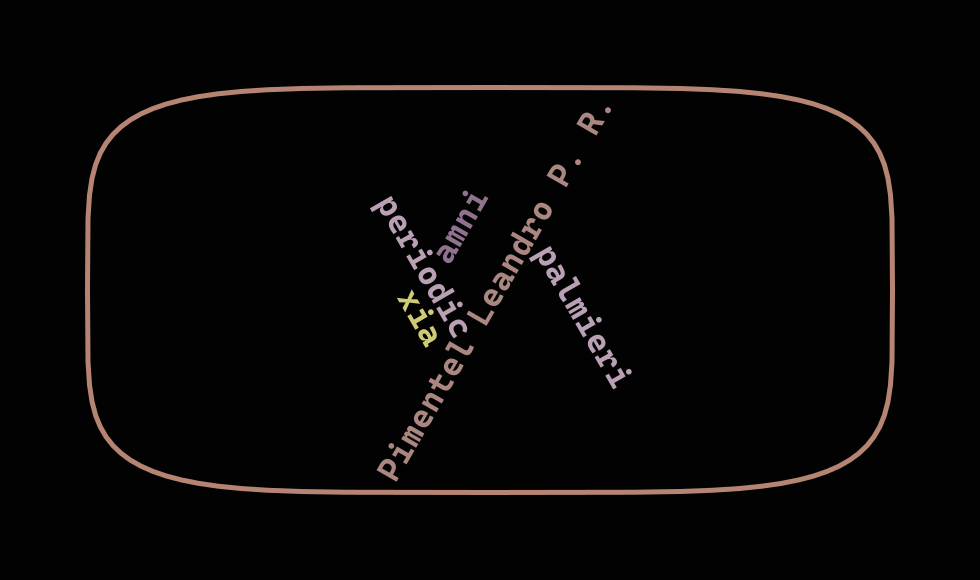

color scheme: :Degas, random size: 5
angles = collect(-5:5)
Language: eng
fonts = "Sitka Bold"
backgroundcolor = :maskcolor
shape(ngon, 800, 400, npoints=4, orientation=0.7853981633974483, color="#D6E8D7", padding=80)
The word "Fournais Søren"(45.277507334947586) is too big. Set maxfontsize = 42.18949029307043.

couldn't load font "Sitka Bold Not-Rotated 36.939", falling back to "Sans Bold Not-Rotated 36.939", expect ugly output.couldn't load font "Sitka Bold Not-Rotated 34.09", falling back to "Sans Bold Not-Rotated 34.09", expect ugly output.couldn't load font "Sitka Bold Not-Rotated 34.0625", falling back to "Sans Bold Not-Rotated 34.0625", expect ugly output.couldn't load font "Sitka Bold Not-Rotated 33.958", falling back to "Sans Bold Not-Rotated 33.958", expect ugly output.


The word "Fournais Søren"(48.372335473500506) is too big. Set maxfontsize = 42.20947522418077.
The word "satellite"(122.98959346236707) is too big. Set maxfontsize = 79.05585622877707.

couldn't load font "Sitka Bold Not-Rotated 31.643", falling back to "Sans Bold Not-Rotated 31.643", expect ugly output.couldn't load font "Sitka Bold Not-Rotated 39.464", falling back to "Sans Bold Not-Rotated 39.464", expect ugly output.couldn't load font "Sitka Bold Not-Rotated 36.42", falling back to "Sans Bold Not-Rotated 36.42", expect ugly output.couldn't load font "Sitka Bold Not-Rotated 36.391", falling back to "Sans Bold Not-Rotated 36.391", expect ugly output.couldn't load font "Sitka Bold Not-Rotated 36.279", falling back to "Sans Bold Not-Rotated 36.279", expect ugly output.couldn't load font "Sitka Bold Not-Rotated 31.657", falling back to "Sans Bold Not-Rotated 31.657", expect ugly output.couldn't load font "Sitka Bold Not-Rotated 92.242", falling back to "Sans Bold Not-Rotated 92.242", expect ugly output.


The word "aggregation"(79.05585622877707) is too big. Set maxfontsize = 52.4483347663751.
The word "aggregation"(71.06246876607842) is too big. Set maxfontsize = 52.29833610074086.
The word "Fournais Søren"(52.29833610074086) is too big. Set maxfontsize = 42.687269298071975.

couldn't load font "Sitka Bold Not-Rotated 59.292", falling back to "Sans Bold Not-Rotated 59.292", expect ugly output.couldn't load font "Sitka Bold Not-Rotated 39.336", falling back to "Sans Bold Not-Rotated 39.336", expect ugly output.couldn't load font "Sitka Bold Not-Rotated 57.751", falling back to "Sans Bold Not-Rotated 57.751", expect ugly output.couldn't load font "Sitka Bold Not-Rotated 53.297", falling back to "Sans Bold Not-Rotated 53.297", expect ugly output.couldn't load font "Sitka Bold Not-Rotated 39.224", falling back to "Sans Bold Not-Rotated 39.224", expect ugly output.


The word "satellite"(87.86615257029939) is too big. Set maxfontsize = 78.4342696981687.


couldn't load font "Sitka Bold Not-Rotated 32.016", falling back to "Sans Bold Not-Rotated 32.016", expect ugly output.couldn't load font "Sitka Bold Not-Rotated 65.899", falling back to "Sans Bold Not-Rotated 65.899", expect ugly output.couldn't load font "Sitka Bold Not-Rotated 58.826", falling back to "Sans Bold Not-Rotated 58.826", expect ugly output.

The word "aggregation"(78.4342696981687) is too big. Set maxfontsize = 52.47600353626608.
▸1. Set spacing = 2; scale = 226.7192247648965


couldn't load font "Sitka Bold Not-Rotated 39.357", falling back to "Sans Bold Not-Rotated 39.357", expect ugly output.┌ Warning: The `findscale!` has performed `maxiter`(5) iterations. The set `density` is not reached. This may be caused by too small background, too big `minfontsize` or unsuitable number of words.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\strategy.jl:152
┌ Warning: Some words are limited to the maximum font size. Please set a `maxfontsize` in `wordcloud` or set a `maxweight` in `processtext`.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\wc-method.jl:67


Aborted after 64 epochs.
▸2. Try setting spacing = 1
Aborted after 126 epochs.
The word "aggregation"(70.89376262129163) is too big. Set maxfontsize = 52.41798158742055.
The word "Fournais Søren"(52.41798158742055) is too big. Set maxfontsize = 42.45581224887122.

couldn't load font "Sitka Bold Not-Rotated 57.614", falling back to "Sans Bold Not-Rotated 57.614", expect ugly output.couldn't load font "Sitka Bold Not-Rotated 53.17", falling back to "Sans Bold Not-Rotated 53.17", expect ugly output.couldn't load font "Sitka Bold Not-Rotated 39.313", falling back to "Sans Bold Not-Rotated 39.313", expect ugly output.


▸3. Try setting scale = 219.9176480219496. The density will be reduced to 0.43906141542175947
Failed after 188 epochs.
These words collide: #MASK# & Fournais Søren, #MASK# & aggregation, 


couldn't load font "Sitka Bold Not-Rotated 31.842", falling back to "Sans Bold Not-Rotated 31.842", expect ugly output.┌ Warning: Some words are limited to the maximum font size. Please set a `maxfontsize` in `wordcloud` or set a `maxweight` in `processtext`.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\wc-method.jl:67
┌ Warning: There are 2 collisions detected. To address this, you might consider increasing the `epochs` or `retry` parameters within the `generate!` function, or reducing the `density` or `spacing` parameters in the `wordcloud` function.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\wc-method.jl:288


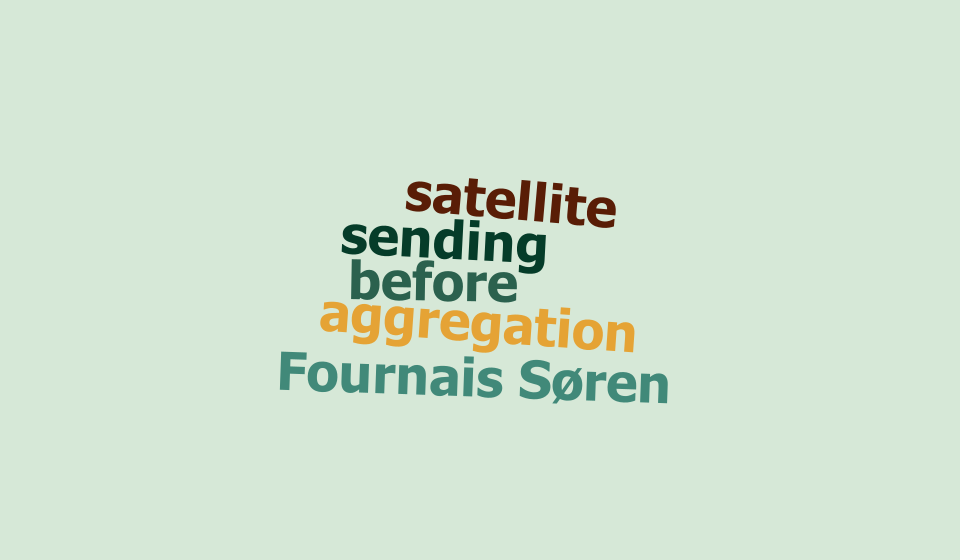

color scheme: :Hokusai3, random size: 3
angles = -45:45
Language: lat
fonts = "Verdana Medium"
backgroundcolor = :maskcolor
shape(box, 800, 400, cornerradius=75, color="#EDEBEC", padding=80)
The word "Gerbi Stéphane LAMA"(81.30400770036152) is too big. Set maxfontsize = 57.71887368630994.
The word "speculative"(131.08064934115797) is too big. Set maxfontsize = 117.05217113766544.
The word "bi-legendrian"(117.05217113766544) is too big. Set maxfontsize = 104.62306096763885.
The word "Gerbi Stéphane LAMA"(94.16448810662942) is too big. Set maxfontsize = 57.77452159683567.
The word "Gerbi Stéphane LAMA"(101.194098706779) is too big. Set maxfontsize = 57.79784770026185.
The word "speculative"(125.19854757414916) is too big. Set maxfontsize = 117.30057455501168.
The word "bi-legendrian"(114.0098562935869) is too big. Set maxfontsize = 104.66541277562308.


┌ Warning: The `findscale!` has performed `maxiter`(5) iterations. The set `density` is not reached. This may be caused by too small background, too big `minfontsize` or unsuitable number of words.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\strategy.jl:152
┌ Warning: Some words are limited to the maximum font size. Please set a `maxfontsize` in `wordcloud` or set a `maxweight` in `processtext`.
└ @ WordCloud C:\Users\Asus\.julia\packages\WordCloud\Rrf5V\src\wc-method.jl:67
┌ Warning: ShiftedQTree cut off: (112, 1126)>1024
└ @ Stuffing.QTrees C:\Users\Asus\.julia\packages\Stuffing\tfnkL\src\qtrees.jl:198


In [ ]:
ber_topic_wordcloud(model, vocab)

In [ ]:
function build_topic_label_map(model, docs, labels)

    K = length(model.topic_centroids)

    topic_to_labels = [Int[] for _ in 1:K]

    for i in eachindex(docs)

        topic, _ = assign_topic(model, docs[i])
        push!(topic_to_labels[topic], labels[i])
    end

    mapping = Dict{Int, Int}()

    for k in 1:K
        if isempty(topic_to_labels[k])
            continue
        end
        mapping[k] = mode(topic_to_labels[k])
    end

    return mapping
end

function evaluate_accuracy(model, docs, labels)

    mapping = build_topic_label_map(model, docs, labels)

    correct = 0
    total = length(docs)

    for i in eachindex(docs)

        topic, _ = assign_topic(model, docs[i])
        pred = get(mapping, topic, -1)

        if pred == labels[i]
            correct += 1
        end
    end

    return correct / total
end

function topic_purity(model, docs, labels)

    K = length(model.topic_centroids)
    topic_labels = [Int[] for _ in 1:K]

    for i in eachindex(docs)
        topic, _ = assign_topic(model, docs[i])
        push!(topic_labels[topic], labels[i])
    end

    total = 0
    correct = 0

    for k in 1:K
        if isempty(topic_labels[k])
            continue
        end

        majority = mode(topic_labels[k])
        correct += count(x -> x == majority, topic_labels[k])
        total += length(topic_labels[k])
    end

    return correct / total
end

function average_intra_inter_similarity(model, docs)

    embeddings = [embed(model.embedder, d) for d in docs]

    n = length(docs)

    intra = Float32[]
    inter = Float32[]

    for i in 1:n
        ti, _ = assign_topic(model, docs[i])

        for j in 1:n
            sim = cosine(embeddings[i], embeddings[j])
            tj, _ = assign_topic(model, docs[j])

            if ti == tj
                push!(intra, sim)
            else
                push!(inter, sim)
            end
        end
    end

    return mean(intra), mean(inter)
end

function topic_coherence(model, vocab; top_n=10)

    S, id2word = topic_word_scores(model, vocab)
    K = size(S, 1)

    coherences = Float32[]

    for k in 1:K

        scores = S[k, :]
        valid = findall(!iszero, scores)

        sorted = sort(valid, by=i->scores[i], rev=true)
        top_ids = sorted[1:min(top_n, length(sorted))]

        words = [id2word[i] for i in top_ids if haskey(id2word, i)]

        if length(words) < 2
            continue
        end

        # similarity between all pairs
        sim_sum = 0f0
        count = 0

        for i in 1:length(words), j in i+1:length(words)
            sim_sum += 1f0  # proxy (możesz podmienić na embedding similarity)
            count += 1
        end

        push!(coherences, sim_sum / max(count, 1))
    end

    return mean(coherences)
end

function evaluate_model(model, train_docs, train_labels, test_docs, test_labels; vocab=nothing)

    println("=== EVALUATION ===")

    acc = evaluate_accuracy(model, test_docs, test_labels)
    println("Accuracy: ", acc)

    purity = topic_purity(model, test_docs, test_labels)
    println("Topic purity: ", purity)

    intra, inter = average_intra_inter_similarity(model, test_docs)
    println("Intra-topic similarity: ", intra)
    println("Inter-topic similarity: ", inter)

    if vocab !== nothing
        coh = topic_coherence(model, vocab)
        println("Topic coherence: ", coh)
    end

    return (
        accuracy = acc,
        purity = purity,
        intra_similarity = intra,
        inter_similarity = inter
    )
end